# TalkEx: Arquitetura Híbrida Cascateada para Classificação de Intenções

> **v1-rayo**: Embeddings E5-large-instruct (1024d) com instruction prefix — motivado por Rayo et al. (2025)

**TCC — Centro de Competências Embrapii em Tecnologias Imersivas (AKCIT)**

Paulo Henrique Vieira do Nascimento &bull; Cauê Cavichioli Leão &bull; Suele Susan Feitosa Sousa

---

### Contexto

A classificação automática de intenções em conversas de atendimento ao cliente é um componente fundamental de sistemas de Information Retrieval (IR) e chatbots inteligentes (Bhalla & Huang, 2025). Construir sistemas robustos para português brasileiro (PT-BR) apresenta desafios específicos: escassez de dados anotados, vocabulário informal em atendimento digital, e a necessidade de operar em cenários multi-turno onde a intenção pode mudar ao longo da conversa.

### Estado da Arte

- **Classificação de intenções PT-BR:** Farfan-Escobedo e Dos Reis (2024) com CNN+BERT (F1=0,87 no Wavy, 22 classes); Bhalla e Huang (2025) com kNN+embeddings; Finardi et al. (2021) com BERTaú (+22% MRR em FAQ); Harris (2025) mostrando que BM25 pode superar embeddings em documentos estruturados.
- **Recuperação híbrida:** SPLADE (Formal et al., 2021), ColBERT (Khattab & Zaharia, 2020), DPR (Karpukhin et al., 2020) consolidaram a complementaridade lexical+semântica. Rayo et al. (2025) demonstram fusão BM25+BGE com +9,5% Recall@10 (α=0,65), mas em textos regulatórios em inglês.
- **Embeddings + classificadores:** Reimers e Gurevych (2019) com Sentence-BERT; Tunstall et al. (2022) com SetFit. Boccardo e Feltrim (2026) confirmam empiricamente que LightGBM (Ke et al., 2017) é competitivo frente a BERT/RoBERTa em PT-BR.
- **Regras em PLN:** SystemT (Chiticariu et al., 2013) e Snorkel (Ratner et al., 2017); motores comerciais (Rasa, Dialogflow) usam regras como overrides rígidos, sem integrá-las como features preditivas suaves.
- **Multi-turno PT-BR:** Zhang et al. (2021), Lyu et al. (2025) permanecem restritos ao inglês; BERTimbau (Souza et al., 2020) fornece codificadores PT-BR robustos, mas ausência de datasets públicos de atendimento multi-turno restringiu o avanço de pipelines híbridos orientados à eficiência.

> *O acoplamento de codificador multilíngue congelado com gradient boosting para classificação multi-turno em PT-BR permanece inédito na literatura.*

---

### Pergunta de pesquisa

> *Como a combinação de recuperação lexical (BM25), embeddings multilíngues congelados e regras
> determinísticas em um pipeline híbrido cascateado pode aprimorar a classificação automática de
> intenções em conversas de atendimento ao cliente em português brasileiro?*

### Hipóteses

| | Hipótese | Métrica principal |
|:---:|:---|:---|
| **H1** | Recuperação híbrida supera paradigmas isolados | MRR |
| **H2** | Embeddings + lexical supera lexical-only | Macro-F1 |
| **H3** | Regras determinísticas complementam a classificação por ML | Macro-F1 |
| **H4** | Inferência cascateada melhora F1 e tempo | Macro-F1 + tempo |

Adicionalmente, comparamos o pipeline completo com baselines de referência (kNN, centróide, LogReg, SVM, LightGBM emb-only) para validar a necessidade de cada componente.

## Arquitetura do TalkEx

```
┌─────────────┐    ┌──────────────┐    ┌───────────────────┐    ┌──────────────┐
│  Conversas   │───▶│ Segmentação  │───▶│ Janelas de        │───▶│  Embeddings  │
│  PT-BR       │    │ de Turnos    │    │ Contexto (5t, s2) │    │  1024 dims   │
└─────────────┘    └──────────────┘    └───────────────────┘    └──────┬───────┘
                                                                       │
                    ┌──────────────┐    ┌───────────────────┐          │
                    │   Regras     │◀───│   LightGBM        │◀─── 1037 features
                    │ 10 regras    │    │   Classificador   │    (1024 emb + 13 eng.)
                    └──────────────┘    └───────────────────┘
```

| Componente | Tecnologia | Referência |
|:---|:---|:---|
| Recuperação lexical | BM25 (Okapi) | Robertson et al., 1996 |
| Instruction prefix | "query: " / "passage: " (protocolo E5) | Wang et al., 2024 |
| Embeddings | intfloat/multilingual-e5-large-instruct (congelado, 1024d) | Wang et al., 2024 |
| Classificação | LightGBM (hiperparâmetros via Optuna, early stopping) | — |
| Regras | 10 regras declarativas, 3 famílias (léxico, regex, contextual) | — |
| Fusão híbrida | Linear (α·sem + (1−α)·lex) e RRF — busca exata por cosseno | Rayo et al., 2025 |


## Protocolo Experimental

| Parâmetro | Valor |
|:---|:---|
| **Dataset** | 2.120 conversas (676 originais + 1.444 sintéticas via Claude Sonnet), 8 classes — HuggingFace, Apache 2.0 |
| **Seeds** | [13, 42, 123, 2024, 999] |
| **Splits** | 70/15/15% estratificados por intenção, nível da conversa |
| **Métrica principal** | Macro-F1 (trata todas as classes igualmente, ideal para desbalanceamento natural) |
| **Teste estatístico** | Wilcoxon signed-rank (α=0,05) — Demšar (2006); não assume normalidade |
| **Intervalo de confiança** | Bootstrap 95% (10.000 reamostras) |
| **Effect size** | Correlação rank-biserial (r_rb) |
| **Infraestrutura** | Google Colab, GPU Tesla T4 |
| **Alinhamento** | v1-fix: segmentação, windowing, features e retrieval alinhados com codebase TalkEx |

**Justificativa metodológica:** Macro-F1 trata igualmente todas as classes independentemente da frequência, propriedade essencial dado o desbalanceamento natural do corpus (reclamação 17,3%, elogio 6,9%). O Wilcoxon signed-rank (Demšar, 2006) foi escolhido por (i) não assumir distribuição normal dos resultados — suposição inadequada para métricas limitadas a [0,1] — e (ii) operar sobre o ranking dos pares de diferenças, sendo adequado para comparações pareadas com N=5 seeds. Bootstrap CI 95% complementa o Wilcoxon estimando o intervalo de confiança da diferença entre variantes — quando o zero está contido no intervalo, a diferença observada é compatível com ausência de efeito real, independentemente do p-valor.

---
# 1. Setup e Dados

In [1]:
# Detectar ambiente
import os
IN_COLAB = 'COLAB_GPU' in os.environ or 'GOOGLE_COLAB' in os.environ.get('GCS_READ_CACHE_BLOCK_SIZE', '')

if IN_COLAB:
    print("🔧 Ambiente: Google Colab")
    !pip install -q sentence-transformers lightgbm rank-bm25 datasets scikit-learn numpy pandas matplotlib seaborn
else:
    print("🔧 Ambiente: Local")
    # Dependências já instaladas via pip install -e ".[dev]"

import warnings
warnings.filterwarnings('ignore')


🔧 Ambiente: Google Colab


In [2]:
import json
import time
import re
import unicodedata
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import StratifiedShuffleSplit

try:
    import lightgbm as lgb
    HAS_LIGHTGBM = True
except ImportError:
    HAS_LIGHTGBM = False
    print("⚠️ LightGBM não disponível, usando LogisticRegression como fallback")

try:
    from sentence_transformers import SentenceTransformer
    HAS_SBERT = True
except ImportError:
    HAS_SBERT = False
    print("⚠️ sentence-transformers não disponível")

# Detecção de GPU
try:
    import torch
    GPU_AVAILABLE = torch.cuda.is_available()
    GPU_NAME = torch.cuda.get_device_name(0) if GPU_AVAILABLE else 'N/A'
except ImportError:
    GPU_AVAILABLE = False
    GPU_NAME = 'N/A'

print(f"NumPy: {np.__version__}")
print(f"LightGBM: {HAS_LIGHTGBM}")
print(f"SentenceTransformer: {HAS_SBERT}")
print(f"GPU disponível: {GPU_AVAILABLE} ({GPU_NAME})")


NumPy: 2.0.2
LightGBM: True
SentenceTransformer: True
GPU disponível: True (NVIDIA RTX PRO 6000 Blackwell Server Edition)


In [3]:
# === CARREGAMENTO DO DATASET ===
# Corpus completo (originais + sintéticas) publicado no HuggingFace.
# Originais: RichardSakaguchiMS/brazilian-customer-service-conversations (676 válidas)
# Sintéticas: geração controlada via Claude Sonnet / OpenRouter (Stage 2 §6)
# Merge: merge_and_push.py

import json
from pathlib import Path
from datasets import load_dataset

import logging
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

HF_REPO = "paulohenriquevn/talkex-augmented-pt-br"

print(f"📥 Carregando corpus de {HF_REPO}...")
ds = load_dataset(HF_REPO, split="train")
print(f"   {len(ds)} registros carregados")

df_original = pd.DataFrame(ds)

# Garantir colunas
if '_synthetic' not in df_original.columns:
    df_original['_synthetic'] = False

# Estatísticas
n_orig = len(df_original[~df_original['_synthetic']])
n_syn = len(df_original[df_original['_synthetic']])

print(f"\n✅ Corpus carregado (custo: $0)")
print(f"   Originais:  {n_orig}")
print(f"   Sintéticas: {n_syn}")
print(f"   Total:      {len(df_original)}")

print(f"\n📊 Distribuição por intenção:")
print(df_original['intent'].value_counts().to_string())

📥 Carregando corpus de paulohenriquevn/talkex-augmented-pt-br...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/946k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2120 [00:00<?, ? examples/s]

   2120 registros carregados

✅ Corpus carregado (custo: $0)
   Originais:  676
   Sintéticas: 1444
   Total:      2120

📊 Distribuição por intenção:
intent
compra             265
reclamacao         265
cancelamento       265
duvida_produto     265
saudacao           265
elogio             265
suporte_tecnico    265
duvida_servico     265


In [ ]:
# Taxonomia de 8 classes de intenção
INTENT_TAXONOMY = [
    "cancelamento",
    "reclamacao",
    "suporte_tecnico",
    "compra",
    "duvida_produto",
    "duvida_servico",
    "saudacao",
    "elogio",
]

NUM_CLASSES = len(INTENT_TAXONOMY)
print(f"📋 Taxonomia: {NUM_CLASSES} classes de intenção")
for i, intent in enumerate(INTENT_TAXONOMY, 1):
    print(f"   {i}. {intent}")


📋 Taxonomia: 8 classes de intenção
   1. cancelamento
   2. reclamacao
   3. suporte_tecnico
   4. compra
   5. duvida_produto
   6. duvida_servico
   7. saudacao
   8. elogio


In [ ]:
# === SEPARAÇÃO: CONVERSAS ORIGINAIS vs SINTÉTICAS ===
# Para avaliação robusta, marcamos quais conversas são sintéticas.
# O test set pode ser filtrado para avaliar exclusivamente em dados reais.

original_conv_ids = set(df_original[~df_original['_synthetic']]['conv_id'].values)
synthetic_conv_ids = set(df_original[df_original['_synthetic']]['conv_id'].values)

print(f"📊 Corpus:")
print(f"   Originais:  {len(original_conv_ids)} conversas")
print(f"   Sintéticas: {len(synthetic_conv_ids)} conversas")
print(f"   Total:      {len(original_conv_ids) + len(synthetic_conv_ids)}")
print(f"\n   IDs originais: prefixo 'conv_'")
print(f"   IDs sintéticas: prefixo 'syn_'")

📊 Corpus:
   Originais:  676 conversas
   Sintéticas: 1444 conversas
   Total:      2120

   IDs originais: prefixo 'conv_'
   IDs sintéticas: prefixo 'syn_'


---
# 2. Pipeline de Processamento

O pipeline segue **6 estágios**:

1. **Segmentação de turnos** com parse dos marcadores `[customer]`/`[agent]` (formato HuggingFace; codebase usa `CUSTOMER:`/`AGENT:` configurável), **merge de turnos consecutivos do mesmo speaker** e normalização **NFKC**;
2. **Janelas deslizantes** de 5 turnos com stride 2, incluindo speaker labels `[CUSTOMER]`/`[AGENT]` no texto renderizado, capturando dependências multi-turno;
3. **Embeddings** com `intfloat/multilingual-e5-large-instruct` (1.024d, congelado, L2-normalizado) usando **instruction prefix** (`passage:` para documentos, `query:` para buscas em recuperação);
4. **Engenharia de features:** 1.024 dims de embeddings concatenados a 13 features engenheiradas — 7 lexicais, 4 estruturais (speaker, turn count) e 2 features binárias de regras (`rule_cancel` e `rule_complaint`, selecionadas por maior variância discriminativa no corpus) — totalizando **1.037 features**;
5. **Classificação com LightGBM**, hiperparâmetros otimizados via Optuna TPE em 20 trials × 5 seeds;
6. **Agregação janela → conversa** por média das probabilidades de saída do classificador seguida de **argmax**, elevando o Macro-F1 em aproximadamente 10 pp em relação à avaliação no nível da janela.

In [ ]:
# === NORMALIZAÇÃO DE TEXTO DE TURNOS (alinhado com codebase segmentation/normalization.py) ===
# Aplica NFKC (canonical + compatibility), strip lines, collapse whitespace horizontal.
# NFKC converte ligatures (ﬁ→fi), frações (½→1/2) e formas de compatibilidade.
_HORIZONTAL_WS = re.compile(r"[^\S\n]+")


def normalize_turn_text(text: str) -> str:
    """NFKC + strip lines + collapse horizontal whitespace."""
    result = unicodedata.normalize("NFKC", text)
    lines = result.split("\n")
    result = "\n".join(line.strip() for line in lines)
    result = _HORIZONTAL_WS.sub(" ", result)
    return result


# === MERGING DE TURNOS CONSECUTIVOS (alinhado com codebase segmentation/merging.py) ===

def merge_consecutive_same_speaker(turns: list[dict]) -> list[dict]:
    """Merge adjacent turns from same speaker with newline separator."""
    if not turns:
        return []
    merged = [dict(turns[0])]
    for turn in turns[1:]:
        if turn["speaker"] == merged[-1]["speaker"]:
            merged[-1]["text"] = merged[-1]["text"] + "\n" + turn["text"]
        else:
            merged.append(dict(turn))
    return merged


# === SEGMENTAÇÃO DE TURNOS ===

SPEAKER_PATTERN = re.compile(r"\[(customer|agent)\]", re.IGNORECASE)


def segment_turns(text: str) -> list[dict]:
    """Segmenta texto em turnos baseado em marcadores [customer]/[agent].

    NOTA: texto sem marcador [customer]/[agent] é atribuído a "customer"
    por padrão. Isso pode afetar features estruturais (is_customer, speaker_count).

    NOTA: O padrão [customer]/[agent] corresponde ao formato do dataset HuggingFace.
    O codebase usa padrão configurável (default: CUSTOMER:/AGENT:).

    Pós-processamento (alinhado com codebase):
    1. Merge de turnos consecutivos do mesmo speaker (merging.py)
    2. Normalização NFKC + whitespace collapse (normalization.py)
    """
    turns = []
    parts = SPEAKER_PATTERN.split(text)

    i = 0
    while i < len(parts):
        if i + 1 < len(parts) and SPEAKER_PATTERN.match(f"[{parts[i]}]"):
            speaker = parts[i].lower()
            content = parts[i + 1].strip() if i + 1 < len(parts) else ""
            if content:
                turns.append({"speaker": speaker, "text": content})
            i += 2
        else:
            content = parts[i].strip()
            if content and not SPEAKER_PATTERN.match(f"[{content}]"):
                turns.append({"speaker": "customer", "text": content})
            i += 1

    # Merge consecutive same-speaker turns (codebase: merging.merge_consecutive_same_speaker)
    turns = merge_consecutive_same_speaker(turns)

    # Normalizar texto dos turnos: NFKC + whitespace (codebase: normalization.normalize_text)
    for turn in turns:
        turn["text"] = normalize_turn_text(turn["text"])

    return turns


# === RENDERIZAÇÃO DE WINDOW TEXT (alinhado com codebase context/rendering.py) ===

def render_window_text(turns: list[dict]) -> str:
    """Render window text com [SPEAKER] labels e newline delimiter.

    Alinhado com codebase: render_speaker_labels=True, render_turn_delimiter='\\n'.
    """
    parts = []
    for turn in turns:
        label = turn["speaker"].upper()
        parts.append(f"[{label}] {turn['text']}")
    return "\n".join(parts)


# === JANELAS DE CONTEXTO ===

WINDOW_SIZE = 5
WINDOW_STRIDE = 2
MIN_WINDOW_SIZE = 1


def build_context_windows(
    turns: list[dict],
    window_size: int = WINDOW_SIZE,
    stride: int = WINDOW_STRIDE,
    min_window_size: int = MIN_WINDOW_SIZE,
) -> list[dict]:
    """Constrói janelas de contexto deslizantes sobre turnos.

    Alinhado com codebase context/windowing.py:
    - While-loop com stride incremental (não for-range)
    - Janelas parciais incluídas se >= min_window_size (include_partial_tail=True)
    - Window text renderizado com speaker labels e newline delimiter
    """
    if not turns:
        return []

    windows = []
    n = len(turns)
    start = 0

    while start < n:
        end = min(start + window_size, n)
        window_turns = turns[start:end]
        actual_size = len(window_turns)

        # Partial window — include if >= min_window_size (codebase tail policy)
        if actual_size < window_size:
            if actual_size < min_window_size:
                break

        window_text = render_window_text(window_turns)
        speakers = set(t["speaker"] for t in window_turns)
        windows.append({
            "window_text": window_text,
            "turns": window_turns,
            "turn_count": actual_size,
            "has_customer": "customer" in speakers,
            "has_agent": "agent" in speakers,
        })

        start += stride

    return windows


# Teste
sample_text = "[customer] Boa tarde, quero cancelar meu plano. [agent] Posso ajudar com isso. [customer] Sim, estou insatisfeito. [agent] Qual o motivo? [customer] O serviço caiu várias vezes. [agent] Entendo, vou processar."
turns = segment_turns(sample_text)
windows = build_context_windows(turns)

print(f"Turnos: {len(turns)}")
for i, t in enumerate(turns):
    print(f"  [{i}] {t['speaker']}: {t['text'][:80]}")
print(f"\nJanelas: {len(windows)}")
for i, w in enumerate(windows):
    preview = w['window_text'].replace('\n', ' | ')[:100]
    print(f"  [{i}] {w['turn_count']} turnos | {preview}")

Turnos: 6
  [0] customer: Boa tarde, quero cancelar meu plano.
  [1] agent: Posso ajudar com isso.
  [2] customer: Sim, estou insatisfeito.
  [3] agent: Qual o motivo?
  [4] customer: O serviço caiu várias vezes.
  [5] agent: Entendo, vou processar.

Janelas: 3
  [0] 5 turnos | [CUSTOMER] Boa tarde, quero cancelar meu plano. | [AGENT] Posso ajudar com isso. | [CUSTOMER] Sim, e
  [1] 4 turnos | [CUSTOMER] Sim, estou insatisfeito. | [AGENT] Qual o motivo? | [CUSTOMER] O serviço caiu várias veze
  [2] 2 turnos | [CUSTOMER] O serviço caiu várias vezes. | [AGENT] Entendo, vou processar.


In [ ]:
# === NORMALIZAÇÃO UNICODE ===

def strip_accents(text: str) -> str:
    """NFD para remoção de diacríticos no matching lexical."""
    nfd = unicodedata.normalize("NFD", text)
    return "".join(c for c in nfd if unicodedata.category(c) != "Mn")


def normalize_for_matching(text: str) -> str:
    """Normaliza para comparação lexical: lowercase + remoção de acentos."""
    return strip_accents(text.lower())


# Teste
assert normalize_for_matching("Não") == "nao"
assert normalize_for_matching("Cancelamento") == "cancelamento"
assert normalize_for_matching("café") == "cafe"
print("✅ Normalização funcionando corretamente")


✅ Normalização funcionando corretamente


## 3. Representação: 1037 Features

| Família | Dims | Descrição |
|:---|:---:|:---|
| Embeddings | 1024 | `intfloat/multilingual-e5-large-instruct`, congelado, L2-normalizado, instruction prefix |
| Lexicais | 7 | char_count, word_count, avg_word_len, ?, !, upper_ratio, digit_ratio |
| Estruturais | 4 | is_customer, is_agent, turn_count, speaker_count |
| Regras (base) | 2 | rule_cancel, rule_complaint (selecionadas por variância no dataset) |
| **Total** | **1037** | |

> **Nota H3:** No experimento H3, o baseline ML-only usa 395 features (sem regras). ML+Rules-feature adiciona 10 features binárias de regras (405 dims total), garantindo comparação limpa.


In [8]:
# === EMBEDDING GENERATION (v1-rayo: E5-large-instruct) ===
# Troca paraphrase-multilingual-MiniLM-L12-v2 (384d, 33M params) por
# intfloat/multilingual-e5-large-instruct (1024d, 560M params).
# Motivação: Rayo et al. (2025) mostra que fusão híbrida só funciona
# quando o componente semântico é forte o suficiente para ser complementar ao BM25.
# E5 usa instruction prefix ("query: " / "passage: ") que melhora retrieval 5-10%.

EMBEDDING_MODEL_NAME = "intfloat/multilingual-e5-large-instruct"
EMBEDDING_DIM = 1024

if HAS_SBERT:
    print(f"\U0001f504 Carregando modelo: {EMBEDDING_MODEL_NAME}...")
    start = time.time()
    embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)
    elapsed = time.time() - start
    EMBEDDING_DIM = embedding_model.get_sentence_embedding_dimension()
    print(f"\u2705 Modelo carregado em {elapsed:.1f}s")
    print(f"   Dimensões: {EMBEDDING_DIM}")
else:
    embedding_model = None
    print("\u26a0\ufe0f Modelo de embeddings não disponível — usando vetores aleatórios")


def generate_embeddings(texts: list[str], batch_size: int = 32, prefix: str = "") -> np.ndarray:
    """Gera embeddings para uma lista de textos.

    Para modelos E5/BGE, usar prefix="passage: " para documentos
    e prefix="query: " para queries de busca (instruction protocol).
    """
    if prefix:
        texts = [f"{prefix}{t}" for t in texts]

    if embedding_model is not None:
        embeddings = embedding_model.encode(
            texts,
            batch_size=batch_size,
            show_progress_bar=len(texts) > 100,
            normalize_embeddings=True,  # L2 normalization
        )
        return np.array(embeddings, dtype=np.float32)
    else:
        # Fallback determinístico para demo sem GPU
        rng = np.random.default_rng(42)
        embs = rng.standard_normal((len(texts), EMBEDDING_DIM)).astype(np.float32)
        norms = np.linalg.norm(embs, axis=1, keepdims=True)
        return embs / norms

🔄 Carregando modelo: intfloat/multilingual-e5-large-instruct...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/128 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_xlm-roberta_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

✅ Modelo carregado em 9.7s
   Dimensões: 1024


In [ ]:
# === EXTRAÇÃO DE FEATURES LEXICAIS ===

def extract_lexical_features(text: str) -> dict[str, float]:
    """Extrai 7 features lexicais de um texto."""
    chars = len(text)
    words = text.split()
    n_words = len(words)
    avg_word_len = np.mean([len(w) for w in words]) if words else 0.0
    questions = text.count("?")
    exclamations = text.count("!")
    alpha_chars = sum(1 for c in text if c.isalpha())
    upper_ratio = sum(1 for c in text if c.isupper()) / alpha_chars if alpha_chars > 0 else 0.0
    digit_ratio = sum(1 for c in text if c.isdigit()) / max(chars, 1)

    return {
        "char_count": float(chars),
        "word_count": float(n_words),
        "avg_word_length": float(avg_word_len),
        "question_count": float(questions),
        "exclamation_count": float(exclamations),
        "uppercase_ratio": float(upper_ratio),
        "digit_ratio": float(digit_ratio),
    }


# === EXTRAÇÃO DE FEATURES ESTRUTURAIS ===
# Considera a presença de customer/agent, número de turnos, diversidade de falantes
def extract_structural_features(window: dict) -> dict[str, float]:
    """Extrai 4 features estruturais de uma janela de contexto."""
    speakers = set(t["speaker"] for t in window["turns"])
    return {
        "is_customer": 1.0 if "customer" in speakers else 0.0,
        "is_agent": 1.0 if "agent" in speakers else 0.0,
        "turn_count": float(window["turn_count"]),
        "speaker_count": float(len(speakers)),
    }


print("✅ Extratores de features definidos")
print(f"   Lexicais: 7 features")
print(f"   Estruturais: 4 features")
print(f"   Embeddings: {EMBEDDING_DIM} features")
print(f"   Regras: 2 features")
print(f"   Total: {7 + 4 + EMBEDDING_DIM + 2} features")


✅ Extratores de features definidos
   Lexicais: 7 features
   Estruturais: 4 features
   Embeddings: 1024 features
   Regras: 2 features
   Total: 1037 features


In [ ]:
# === MOTOR DE REGRAS v2 — PRECISION BOOSTERS ===
# Redesenhado para resolver 4 problemas da v1:
# P1: Falsos positivos ("oi", "obrigado") → keywords genéricas removidas
# P2: Sobreposição entre classes → min_keywords exige co-ocorrência
# P3: Override ingênuo → substituído por confidence-gated (em H3)
# P4: Redundância com embeddings → regras focam em PRECISION, não recall
#
# Cada regra agora tem:
# - negation_words: se alguma aparece ANTES da keyword, match é anulado
# - min_keywords: número mínimo de keywords que devem co-ocorrer (default 1)
# - exclusive_to: se outra regra de classe diferente também dispara, match é anulado

NEGATION_WORDS = ["nao", "nem", "nunca", "jamais", "sem", "nenhum", "nenhuma"]

RULES_V2 = [
    {
        "rule_id": "rule_cancel",
        "intent": "cancelamento",
        "type": "lexical",
        "keywords": ["cancelar", "cancelamento", "cancela", "desistir",
                     "encerrar contrato", "rescindir", "cancelei", "cancele",
                     "quero cancelar", "desisto"],
        "min_keywords": 1,  # "cancelar" sozinho é forte o suficiente
    },
    {
        "rule_id": "rule_complaint",
        "intent": "reclamacao",
        "type": "lexical",
        "keywords": ["reclamacao", "reclamar", "reclamando", "absurdo",
                     "inadmissivel", "procon", "anatel", "reclame aqui",
                     "ouvidoria", "revoltado", "indignado",
                     "palhacada", "vergonha", "descaso"],
        # Removido: "insatisfeito" (aparece em cancelamentos também)
        "min_keywords": 1,
    },
    {
        "rule_id": "rule_support",
        "intent": "suporte_tecnico",
        "type": "lexical",
        "keywords": ["nao funciona", "nao esta funcionando", "problema tecnico",
                     "bug", "travou", "travando", "nao conecta",
                     "sem sinal", "caiu a conexao", "nao carrega", "tela azul"],
        # Removido: "erro" (muito genérico), "resetar/reiniciar/configurar/instalar/atualizar"
        # (ações, não problemas)
        "min_keywords": 1,
    },
    {
        "rule_id": "rule_purchase",
        "intent": "compra",
        "type": "lexical",
        "keywords": ["quero comprar", "como compro", "onde compro",
                     "quanto custa", "pagamento", "parcela", "desconto", "promocao",
                     "carrinho", "finalizar compra", "comprei", "adquirir", "contratar"],
        # Removido: "preco", "valor", "pedido" (muito genéricos)
        "min_keywords": 1,
    },
    {
        "rule_id": "rule_product_question",
        "intent": "duvida_produto",
        "type": "lexical",
        "keywords": ["especificacao", "caracteristica", "funcionalidade",
                     "garantia", "manual", "compativel", "ficha tecnica",
                     "capacidade", "dimensao"],
        # Removido: "como funciona" (sobrepõe com duvida_servico),
        # "tamanho/modelo/versao/cor" (muito genéricos)
        "min_keywords": 2,  # Exige co-ocorrência para evitar falso positivo
    },
    {
        "rule_id": "rule_service_question",
        "intent": "duvida_servico",
        "type": "lexical",
        "keywords": ["horario de funcionamento", "prazo de entrega",
                     "politica de troca", "reembolso", "frete",
                     "disponibilidade", "agendamento", "agendar"],
        # Removido: "devolver/troca" (sobrepõe com reclamacao),
        # "entrega/prazo" (muito genéricos), "como faco para" (genérico)
        "min_keywords": 1,
    },
    {
        "rule_id": "rule_greeting",
        "intent": "saudacao",
        "type": "regex",
        # v2: Removido "oi" (dispara em 81% das conversas).
        # Mantém apenas saudações multi-palavra que são inequívocas.
        "pattern": r"\b(bom dia|boa tarde|boa noite|tudo bem)\b",
        "min_keywords": 1,
    },
    {
        "rule_id": "rule_praise",
        "intent": "elogio",
        "type": "lexical",
        # v2: Removido "obrigado/agradeco" (cortesia universal).
        # Mantém apenas elogios inequívocos.
        "keywords": ["parabens", "excelente", "otimo atendimento", "muito bom",
                     "maravilhoso", "nota 10", "recomendo", "adorei",
                     "amei", "impecavel"],
        "min_keywords": 1,
    },
    {
        "rule_id": "rule_escalated_cancel",
        "intent": "cancelamento",
        "type": "contextual_occurs_after",
        "first": "problema",
        "second": "cancelar",
        "min_keywords": 1,
    },
    {
        "rule_id": "rule_repeated_error",
        "intent": "suporte_tecnico",
        "type": "contextual_repeated",
        "keyword": "erro",
        "min_count": 2,
        "min_keywords": 1,
    },
]


def evaluate_rules(text: str) -> dict[str, float]:
    """Avalia regras v2 com negation-awareness e co-occurrence.

    Retorna dict {rule_id: 0.0 ou 1.0} para cada regra.
    Negação anula match: "não quero cancelar" → rule_cancel = 0.0
    """
    normalized = normalize_for_matching(text)
    results = {}

    for rule in RULES_V2:
        rule_id = rule["rule_id"]
        matched_count = 0

        if rule["type"] == "lexical":
            for kw in rule["keywords"]:
                kw_norm = normalize_for_matching(kw)
                pos = normalized.find(kw_norm)
                if pos >= 0:
                    # Negation check: procura palavras de negação nas 30 chars antes da keyword
                    context_before = normalized[max(0, pos - 30):pos]
                    negated = any(neg in context_before.split() for neg in NEGATION_WORDS)
                    if not negated:
                        matched_count += 1

        elif rule["type"] == "regex":
            import re as _re
            matches = list(_re.finditer(rule["pattern"], normalized))
            for m in matches:
                pos = m.start()
                context_before = normalized[max(0, pos - 30):pos]
                negated = any(neg in context_before.split() for neg in NEGATION_WORDS)
                if not negated:
                    matched_count += 1

        elif rule["type"] == "contextual_occurs_after":
            first_pos = normalized.find(normalize_for_matching(rule["first"]))
            second_pos = normalized.find(normalize_for_matching(rule["second"]))
            if first_pos >= 0 and second_pos > first_pos:
                matched_count = 1

        elif rule["type"] == "contextual_repeated":
            kw = normalize_for_matching(rule["keyword"])
            if normalized.count(kw) >= rule["min_count"]:
                matched_count = 1

        # Co-occurrence check
        min_kw = rule.get("min_keywords", 1)
        results[rule_id] = 1.0 if matched_count >= min_kw else 0.0

    return results


# Teste
test_cases = [
    ("Quero cancelar meu plano, estou insatisfeito", {"rule_cancel": 1.0}),
    ("Não quero cancelar, só quero entender o serviço", {"rule_cancel": 0.0}),
    ("Oi, bom dia, preciso de ajuda", {"rule_greeting": 1.0}),
    ("Oi, quero comprar um produto", {"rule_greeting": 0.0}),  # "oi" removido
    ("Obrigado pelo atendimento", {"rule_praise": 0.0}),  # "obrigado" removido
    ("Parabéns, excelente atendimento", {"rule_praise": 1.0}),
    ("O app não funciona, está travando", {"rule_support": 1.0}),
]

print("Testes do sistema de regras v2:")
for text, expected_subset in test_cases:
    result = evaluate_rules(text)
    ok = all(result.get(k, 0.0) == v for k, v in expected_subset.items())
    status = "✅" if ok else "❌"
    matched = {k: v for k, v in result.items() if v > 0}
    checked = {k: result.get(k, 0.0) for k in expected_subset}
    print(f"  {status} \"{text[:60]}\"")
    print(f"     Esperado: {expected_subset} | Obtido: {checked}")

Testes do sistema de regras v2:
  ✅ "Quero cancelar meu plano, estou insatisfeito"
     Esperado: {'rule_cancel': 1.0} | Obtido: {'rule_cancel': 1.0}
  ✅ "Não quero cancelar, só quero entender o serviço"
     Esperado: {'rule_cancel': 0.0} | Obtido: {'rule_cancel': 0.0}
  ✅ "Oi, bom dia, preciso de ajuda"
     Esperado: {'rule_greeting': 1.0} | Obtido: {'rule_greeting': 1.0}
  ✅ "Oi, quero comprar um produto"
     Esperado: {'rule_greeting': 0.0} | Obtido: {'rule_greeting': 0.0}
  ✅ "Obrigado pelo atendimento"
     Esperado: {'rule_praise': 0.0} | Obtido: {'rule_praise': 0.0}
  ✅ "Parabéns, excelente atendimento"
     Esperado: {'rule_praise': 1.0} | Obtido: {'rule_praise': 1.0}
  ✅ "O app não funciona, está travando"
     Esperado: {'rule_support': 1.0} | Obtido: {'rule_support': 1.0}


In [11]:
# === ESTATÍSTICAS DESCRITIVAS DO CORPUS ===
# Análise exploratória dos rótulos antes do treinamento.
# A auditoria de qualidade dos rótulos é feita via cross-validation
# do modelo treinado (seção 5.1 — após otimização de hiperparâmetros).

print("📊 Estatísticas descritivas do corpus")
print("=" * 50)

valid = df_original[df_original['intent'].isin(INTENT_TAXONOMY)]
print(f"   Conversas válidas: {len(valid)}")
print(f"   Originais: {len(valid[~valid['_synthetic']])}")
print(f"   Sintéticas: {len(valid[valid['_synthetic']])}")

print(f"\n📊 Distribuição por classe:")
for intent in INTENT_TAXONOMY:
    n = len(valid[valid['intent'] == intent])
    n_orig = len(valid[(valid['intent'] == intent) & (~valid['_synthetic'])])
    n_syn = n - n_orig
    print(f"   {intent:20s}: {n:4d} ({n_orig} originais, {n_syn} sintéticas)")

# Cobertura das regras por classe (informativo, não auditoria)
print(f"\n📊 Cobertura do motor de regras por classe:")
for intent in INTENT_TAXONOMY:
    subset = valid[valid['intent'] == intent]
    covered = 0
    for _, row in subset.iterrows():
        rule_res = evaluate_rules(str(row['text']))
        intent_rules = [r for r in RULES_V2 if r['intent'] == intent]
        if any(rule_res.get(r['rule_id'], 0) > 0 for r in intent_rules):
            covered += 1
    pct = covered / len(subset) * 100 if len(subset) > 0 else 0
    print(f"   {intent:20s}: {covered}/{len(subset)} ({pct:.0f}%)")

📊 Estatísticas descritivas do corpus
   Conversas válidas: 2120
   Originais: 676
   Sintéticas: 1444

📊 Distribuição por classe:
   cancelamento        :  265 (79 originais, 186 sintéticas)
   reclamacao          :  265 (84 originais, 181 sintéticas)
   suporte_tecnico     :  265 (88 originais, 177 sintéticas)
   compra              :  265 (85 originais, 180 sintéticas)
   duvida_produto      :  265 (80 originais, 185 sintéticas)
   duvida_servico      :  265 (87 originais, 178 sintéticas)
   saudacao            :  265 (88 originais, 177 sintéticas)
   elogio              :  265 (85 originais, 180 sintéticas)

📊 Cobertura do motor de regras por classe:
   cancelamento        : 265/265 (100%)
   reclamacao          : 97/265 (37%)
   suporte_tecnico     : 108/265 (41%)
   compra              : 181/265 (68%)
   duvida_produto      : 5/265 (2%)
   duvida_servico      : 64/265 (24%)
   saudacao            : 140/265 (53%)
   elogio              : 140/265 (53%)


---
# 4. Preparação do Corpus

O corpus TalkEx é composto por **2.120 conversas** de atendimento ao cliente em português brasileiro (PT-BR), distribuídas igualmente em 8 classes de intenção (265 conversas por classe): cancelamento, reclamação, suporte técnico, compra, dúvida sobre produto, dúvida sobre serviço, saudação e elogio.

**Origem:** A base de dados original retirada do HuggingFace `RichardSakaguchiMS/brazilian-customer-service-conversations` contava com **944 conversas**, das quais restaram **676 após a exclusão da categoria "outros"**, cuja ampla diversidade temática poderia prejudicar a consistência da classificação de intenções.

**Balanceamento:** Para realizar o balanceamento perfeito das classes, o subconjunto resultante foi expandido com **1.444 conversas sintéticas geradas via Claude Sonnet**.

**Disponibilidade:** O dataset consolidado está publicado e disponível na plataforma HuggingFace sob o identificador `paulohenriquevn/talkex-augmented-pt-br`, licenciado sob a licença **Apache 2.0**.

**Distribuição original (antes do balanceamento):** reclamação 17,3%, elogio 6,9% (corpus desbalanceado, motivando o uso de Macro-F1 como métrica primária).

In [12]:
# === PREPARAÇÃO DO CORPUS ===

SEEDS = [13, 42, 123, 2024, 999]

# NOTA METODOLÓGICA: StratifiedShuffleSplit estratifica apenas por intenção,
# não por origem (original/sintética). Com ratio ~2:1 de sintéticas para
# originais, splits podem ter proporções desequilibradas por origem.

# Processar todas as conversas: segmentar → janelas → features
print("🔄 Processando corpus completo...")
start_time = time.time()

conversations = []
all_windows = []

for idx, row in df_original.iterrows():
    intent = str(row['intent']).lower().strip()

    # Filtrar classe "outros" (conforme paper: 8 classes)
    if intent == 'outros' or intent not in INTENT_TAXONOMY:
        continue

    # Segmentar turnos a partir do texto (formato [customer]/[agent])
    text = str(row['text'])
    turns = segment_turns(text)

    if len(turns) < 2:
        continue

    windows = build_context_windows(turns)

    conv_record = {
        "conv_id": row['conv_id'],
        "text": row['text'],
        "intent": intent,
        "turns": turns,
        "n_turns": len(turns),
        "windows": windows,
        "n_windows": len(windows),
    }
    conversations.append(conv_record)

    for w_idx, window in enumerate(windows):
        all_windows.append({
            "conv_id": row['conv_id'],
            "window_idx": w_idx,
            "window_text": window["window_text"],
            "intent": intent,
            **window,
        })

elapsed = time.time() - start_time
print(f"✅ Corpus processado em {elapsed:.1f}s")
print(f"   Conversas válidas: {len(conversations)}")
print(f"   Janelas de contexto: {len(all_windows)}")
print(f"   Média de janelas/conversa: {len(all_windows)/max(len(conversations),1):.1f}")

# Mapas auxiliares para splits
intents_per_conv = {c["conv_id"]: c["intent"] for c in conversations}
conv_ids = np.array([w["conv_id"] for w in all_windows])

# Distribuição de intenções
intent_dist = Counter(c["intent"] for c in conversations)
print(f"\n📊 Distribuição de intenções:")
for intent, count in sorted(intent_dist.items(), key=lambda x: -x[1]):
    print(f"   {intent}: {count} ({100*count/len(conversations):.1f}%)")


🔄 Processando corpus completo...
✅ Corpus processado em 0.1s
   Conversas válidas: 2120
   Janelas de contexto: 8579
   Média de janelas/conversa: 4.0

📊 Distribuição de intenções:
   compra: 265 (12.5%)
   reclamacao: 265 (12.5%)
   cancelamento: 265 (12.5%)
   duvida_produto: 265 (12.5%)
   saudacao: 265 (12.5%)
   elogio: 265 (12.5%)
   suporte_tecnico: 265 (12.5%)
   duvida_servico: 265 (12.5%)


In [13]:
# === GERAÇÃO DE EMBEDDINGS PARA TODO O CORPUS ===

print("🔄 Gerando embeddings para todas as janelas...")
window_texts = [w["window_text"] for w in all_windows]

start_time = time.time()
all_embeddings = generate_embeddings(window_texts, prefix="passage: ")  # E5 instruction prefix
elapsed = time.time() - start_time

print(f"✅ Embeddings gerados em {elapsed:.1f}s")
print(f"   Shape: {all_embeddings.shape}")
print(f"   Throughput: {len(window_texts)/elapsed:.0f} janelas/s")


🔄 Gerando embeddings para todas as janelas...


Batches:   0%|          | 0/269 [00:00<?, ?it/s]

✅ Embeddings gerados em 4.6s
   Shape: (8579, 1024)
   Throughput: 1849 janelas/s


In [14]:
# === CONSTRUÇÃO DA MATRIZ DE FEATURES ===

print(f"🔄 Construindo matriz de features ({13 + EMBEDDING_DIM} dimensões)...")

# Features para cada janela
feature_records = []
for i, window in enumerate(all_windows):
    # Lexicais (7)
    lex = extract_lexical_features(window["window_text"])
    # Estruturais (4)
    struct = extract_structural_features(window)
    # Regras (2: rule_cancel + rule_complaint — as que têm variância no dataset)
    rules = evaluate_rules(window["window_text"])
    rule_features = {
        # NOTA: apenas rule_cancel e rule_complaint no pipeline base por
        # apresentarem maior variância e poder discriminativo no dataset.
        # As demais 8 regras são avaliadas como features adicionais em H3
        # (ML+Rules-feature → 405 dims com todas as 10 regras).
        "rule_cancel": rules.get("rule_cancel", 0.0),
        "rule_complaint": rules.get("rule_complaint", 0.0),
    }

    feature_records.append({**lex, **struct, **rule_features})

# Montar matriz
df_features = pd.DataFrame(feature_records)
X_non_emb = df_features.values  # (N, 13)
X_full = np.hstack([X_non_emb, all_embeddings])  # (N, 13 + EMBEDDING_DIM)

# Labels
y_labels = np.array([w["intent"] for w in all_windows])
conv_ids = np.array([w["conv_id"] for w in all_windows])

print(f"✅ Matriz de features construída")
print(f"   X_full shape: {X_full.shape} (esperado: N × {13 + EMBEDDING_DIM})")
print(f"   Features não-embedding: {X_non_emb.shape[1]} (7 lex + 4 struct + 2 rules = 13)")
print(f"   Features embedding: {all_embeddings.shape[1]} ({EMBEDDING_DIM})")
print(f"   Total: {X_full.shape[1]}")


🔄 Construindo matriz de features (1037 dimensões)...
✅ Matriz de features construída
   X_full shape: (8579, 1037) (esperado: N × 1037)
   Features não-embedding: 13 (7 lex + 4 struct + 2 rules = 13)
   Features embedding: 1024 (1024)
   Total: 1037


---
# 5. Otimização de Hiperparâmetros

Busca bayesiana (TPE) pelos melhores hiperparâmetros do LightGBM usando **Optuna**. O **conjunto de validação (15%)** é o critério de seleção. O conjunto de teste **nunca** é utilizado nesta etapa.

| Hiperparâmetro | Espaço de busca | Descrição |
|:---|:---|:---|
| `num_leaves` | [8, 128] | Complexidade da árvore |
| `learning_rate` | [0.01, 0.3] (log) | Taxa de aprendizado |
| `min_child_samples` | [3, 30] | Mínimo de amostras por folha |
| `subsample` | [0.6, 1.0] | Fração de amostras por iteração |
| `colsample_bytree` | [0.6, 1.0] | Fração de features por árvore |
| `reg_alpha` | [1e-8, 10] (log) | Regularização L1 |
| `reg_lambda` | [1e-8, 10] (log) | Regularização L2 |

20 trials × 5 seeds = 100 treinos. Parâmetros otimizados em 397 features (MiniLM-384d, v1-fix) e reutilizados em 1037 features (E5-1024d, v1-rayo) e reutilizados nas variantes para isolar o efeito das features, não dos hiperparâmetros.

In [ ]:
# === HIPERPARÂMETROS OTIMIZADOS (cache) ===
# Resultado da busca bayesiana (Optuna TPE, 20 trials × 5 seeds).
# Para re-otimizar, execute a célula seguinte (desabilitada por padrão).

# NOTA: codebase defaults: n_estimators=100, num_leaves=31, random_state=42.
# Hiperparâmetros otimizados via Optuna para 397 features (MiniLM-384d).
# v1-rayo usa E5-1024d (1037 features) — re-otimização recomendada.
# Reutilizados nas variantes de H2 (13 dims) e H3 (395/405 dims) para
# isolar o efeito das features, não dos hiperparâmetros. Isso pode
# sub-otimizar variantes com dimensionalidades muito diferentes.
BEST_LGB_PARAMS = {
    "num_leaves": 9,
    "learning_rate": 0.11857581301373854,
    "min_child_samples": 27,
    "subsample": 0.9186007623689508,
    "colsample_bytree": 0.9910290073976764,
    "reg_alpha": 2.0474533383727786e-06,
    "reg_lambda": 5.153289545145567e-07,
}

print("✅ Hiperparâmetros carregados do cache (Optuna não executado)")
print(f"   Macro-F1 (val): 0.7352 vs default: 0.7258 (Δ=+0.0094)")
for k, v in BEST_LGB_PARAMS.items():
    print(f"   {k}: {v}")

✅ Hiperparâmetros carregados do cache (Optuna não executado)
   Macro-F1 (val): 0.7352 vs default: 0.7258 (Δ=+0.0094)
   num_leaves: 9
   learning_rate: 0.11857581301373854
   min_child_samples: 27
   subsample: 0.9186007623689508
   colsample_bytree: 0.9910290073976764
   reg_alpha: 2.0474533383727786e-06
   reg_lambda: 5.153289545145567e-07


In [ ]:
# === OTIMIZAÇÃO DE HIPERPARÂMETROS (DESABILITADA) ===
# Para re-executar: mude RUN_OPTUNA para True
RUN_OPTUNA = False

if RUN_OPTUNA:
    # === OTIMIZAÇÃO DE HIPERPARÂMETROS DO LIGHTGBM (Optuna) ===
    # Busca bayesiana (TPE) — mais eficiente que grid search exaustivo.
    # Usa val set (15%) para seleção, test set nunca é tocado.
    
    print("=" * 70)
    print("OTIMIZAÇÃO DE HIPERPARÂMETROS — LightGBM + Optuna")
    print("=" * 70)
    
    try:
        import optuna
    except ImportError:
        import subprocess
        subprocess.check_call(["pip", "install", "-q", "optuna"])
        import optuna
    
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    
    N_TRIALS = 20  # 20 trials × 5 seeds = 100 treinos (TPE converge rápido)
    
    if HAS_LIGHTGBM:
    
        # Pré-computar splits para todas as seeds (evitar recalcular a cada trial)
        splits = {}
        for seed in SEEDS:
            conv_list = np.unique(conv_ids)
            conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]
    
            sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
            train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
            test_val_convs = conv_list[test_val_idx]
            test_val_intents = [conv_intent_list[i] for i in test_val_idx]
            sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
            val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))
    
            train_convs = set(conv_list[train_idx])
            val_convs = set(test_val_convs[val_idx])
    
            train_mask = np.array([c in train_convs for c in conv_ids])
            val_mask = np.array([c in val_convs for c in conv_ids])
    
            splits[seed] = {
                "X_train": X_full[train_mask], "y_train": y_labels[train_mask],
                "X_val": X_full[val_mask], "y_val": y_labels[val_mask],
            }
    
        def objective(trial):
            params = {
                "num_leaves": trial.suggest_int("num_leaves", 8, 128),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                "min_child_samples": trial.suggest_int("min_child_samples", 3, 30),
                "subsample": trial.suggest_float("subsample", 0.6, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
                "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
                "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            }
    
            f1_scores = []
            for seed in SEEDS:
                s = splits[seed]
                clf = lgb.LGBMClassifier(
                    **params, n_estimators=300, random_state=seed, verbose=-1,
                )
                clf.fit(
                    s["X_train"], s["y_train"],
                    eval_set=[(s["X_val"], s["y_val"])],
                    callbacks=[lgb.early_stopping(10, verbose=False)],
                )
                y_pred = clf.predict(s["X_val"])
                f1_scores.append(f1_score(s["y_val"], y_pred, average='macro', zero_division=0))
    
            return np.mean(f1_scores)
    
        print(f"   {N_TRIALS} trials × {len(SEEDS)} seeds = {N_TRIALS * len(SEEDS)} treinos")
        print(f"   Busca bayesiana (TPE) — Optuna v{optuna.__version__}")
    
        study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
        study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    
        # Extrair melhores parâmetros
        BEST_LGB_PARAMS = study.best_params
    
        # Avaliar default para comparação
        default_trial = objective(
            optuna.trial.FixedTrial({
                "num_leaves": 31, "learning_rate": 0.1, "min_child_samples": 20,
                "subsample": 1.0, "colsample_bytree": 1.0,
                "reg_alpha": 1e-8, "reg_lambda": 1e-8,
            })
        )
    
        print(f"\n📊 Top 5 trials:")
        top5 = sorted(study.trials, key=lambda t: t.value if t.value else 0, reverse=True)[:5]
        for rank, trial in enumerate(top5, 1):
            p = trial.params
            marker = " ← MELHOR" if trial.number == study.best_trial.number else ""
            print(f"   {rank}. leaves={p['num_leaves']:3d}, lr={p['learning_rate']:.4f}, "
                  f"min_child={p['min_child_samples']:2d}, "
                  f"subsample={p['subsample']:.2f}  →  F1={trial.value:.4f}{marker}")
    
        print(f"\n✅ Parâmetros selecionados: ")
        for k, v in BEST_LGB_PARAMS.items():
            print(f"   {k}: {v}")
        print(f"\n   Macro-F1 (val): {study.best_value:.4f} vs default: {default_trial:.4f} "
              f"(Δ={study.best_value - default_trial:+.4f})")
    
    else:
        BEST_LGB_PARAMS = {"num_leaves": 31, "learning_rate": 0.1, "min_child_samples": 20,
                           "subsample": 1.0, "colsample_bytree": 1.0,
                           "reg_alpha": 1e-8, "reg_lambda": 1e-8}
        print("⚠️ LightGBM não disponível — usando parâmetros default")
else:
    print("⏭️ Optuna desabilitado — usando parâmetros da célula anterior")
    print("   Para re-otimizar: mude RUN_OPTUNA = True nesta célula")


⏭️ Optuna desabilitado — usando parâmetros da célula anterior
   Para re-otimizar: mude RUN_OPTUNA = True nesta célula


## 5.1 Auditoria de Qualidade dos Rótulos (Cross-Validation)

Avaliamos a qualidade dos rótulos do corpus usando **leave-one-seed-out cross-validation**:
- Para cada seed, treinamos o LightGBM otimizado no train set
- Predizemos no test set e comparamos com os rótulos originais
- Conversas onde **todas as 5 seeds concordam em um rótulo diferente** do original são candidatas a erro de rotulação

Esta abordagem é mais robusta que auditoria por regras lexicais, porque usa o próprio modelo treinado — que aprende padrões semânticos (embeddings) além de lexicais.

**Critérios:**
- **Consistente**: modelo concorda com o rótulo em ≥50% das seeds em que foi avaliado
- **Discordante**: modelo discorda em **todas** as seeds (0% de concordância) → candidata a revisão
- **Incerto**: concordância parcial (0% < concordância < 50%)

In [17]:
# === AUDITORIA DE QUALIDADE DOS RÓTULOS (CROSS-VALIDATION) ===
# Método: treinar modelo em cada seed, coletar predições por conversa,
# identificar discordâncias sistemáticas entre rótulo e predição.
# Normaliza pelo número de seeds em que cada conversa foi avaliada.

print("=" * 70)
print("AUDITORIA DE RÓTULOS — Cross-Validation com LightGBM")
print("=" * 70)

# Coletar predições por conversa em cada seed
conv_predictions = {}  # {conv_id: [pred_seed1, pred_seed2, ...]}
conv_true_labels = {}  # {conv_id: true_label}

for seed in SEEDS:
    conv_list = np.unique(conv_ids)
    conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
    test_val_convs = conv_list[test_val_idx]
    test_val_intents = [conv_intent_list[i] for i in test_val_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))

    train_convs = set(conv_list[train_idx])
    val_convs = set(test_val_convs[val_idx])
    test_convs_set = set(test_val_convs[test_idx])

    train_mask = np.array([c in train_convs for c in conv_ids])
    val_mask = np.array([c in val_convs for c in conv_ids])
    test_mask = np.array([c in test_convs_set for c in conv_ids])

    # Treinar modelo
    if HAS_LIGHTGBM:
        clf_audit = lgb.LGBMClassifier(**BEST_LGB_PARAMS, n_estimators=300, random_state=seed, verbose=-1)
        clf_audit.fit(X_full[train_mask], y_labels[train_mask],
                      eval_set=[(X_full[val_mask], y_labels[val_mask])],
                      callbacks=[lgb.early_stopping(10, verbose=False)])
    else:
        clf_audit = LogisticRegression(max_iter=2000, random_state=seed)
        clf_audit.fit(X_full[train_mask], y_labels[train_mask])

    # Predizer no test set — agregar por conversa (média de probabilidades)
    proba_test = clf_audit.predict_proba(X_full[test_mask])
    classes = clf_audit.classes_
    test_conv_ids_arr = conv_ids[test_mask]
    test_labels_arr = y_labels[test_mask]

    conv_proba_agg = {}
    for i, cid in enumerate(test_conv_ids_arr):
        if cid not in conv_proba_agg:
            conv_proba_agg[cid] = []
            conv_true_labels[cid] = test_labels_arr[i]
        conv_proba_agg[cid].append(proba_test[i])

    for cid, probas in conv_proba_agg.items():
        mean_proba = np.mean(probas, axis=0)
        pred = classes[np.argmax(mean_proba)]
        if cid not in conv_predictions:
            conv_predictions[cid] = []
        conv_predictions[cid].append(str(pred))  # str() to avoid np.str_

# === Análise de concordância (normalizada por nº de avaliações) ===
consistent = 0
discordant = 0
uncertain = 0
discordant_examples = []

for cid, preds in conv_predictions.items():
    true_label = conv_true_labels[cid]
    n_total = len(preds)
    n_agree = sum(1 for p in preds if p == true_label)
    agree_ratio = n_agree / n_total  # Normalizar!

    if agree_ratio >= 0.5:  # Maioria concorda com o rótulo
        consistent += 1
    elif agree_ratio == 0:  # Nenhuma seed concorda
        discordant += 1
        if len(discordant_examples) < 20:
            from collections import Counter as _Counter
            pred_counts = _Counter(preds)
            model_label = pred_counts.most_common(1)[0][0]
            is_syn = str(cid).startswith("syn_")
            text_preview = ""
            for _, row in df_original[df_original['conv_id'] == cid].iterrows():
                text_preview = str(row['text'])[:150]
            discordant_examples.append({
                'conv_id': cid,
                'true': true_label,
                'model': model_label,
                'votes': dict(pred_counts),
                'n_seeds': n_total,
                'synthetic': is_syn,
                'preview': text_preview,
            })
    else:
        uncertain += 1

total_audited = consistent + discordant + uncertain
accuracy_cv = consistent / total_audited * 100 if total_audited > 0 else 0

# Distribuição de seeds por conversa
seeds_per_conv = [len(preds) for preds in conv_predictions.values()]
print(f"\n   Conversas avaliadas: {total_audited}")
print(f"   Seeds por conversa: min={min(seeds_per_conv)}, max={max(seeds_per_conv)}, "
      f"mediana={np.median(seeds_per_conv):.0f}, média={np.mean(seeds_per_conv):.1f}")

print(f"\n📊 Resultado da auditoria (N={total_audited}):")
print(f"   ✅ Consistentes (modelo concorda ≥50% das seeds): {consistent:5d} ({consistent/total_audited*100:5.1f}%)")
print(f"   ❌ Discordantes (modelo discorda em TODAS seeds):  {discordant:5d} ({discordant/total_audited*100:5.1f}%)")
print(f"   ⚠️  Incertos (modelo discorda em parte):            {uncertain:5d} ({uncertain/total_audited*100:5.1f}%)")
print(f"\n   Acurácia estimada (cross-validation): {accuracy_cv:.1f}%")

# Separar por origem
conv_origin = {}
for cid in conv_predictions:
    conv_origin[cid] = "sintética" if str(cid).startswith("syn_") else "original"

for origin in ["original", "sintética"]:
    cids = [c for c in conv_predictions if conv_origin[c] == origin]
    if not cids:
        continue
    n_cons = sum(1 for c in cids
                 if sum(1 for p in conv_predictions[c] if p == conv_true_labels[c]) / len(conv_predictions[c]) >= 0.5)
    n_disc = sum(1 for c in cids
                 if sum(1 for p in conv_predictions[c] if p == conv_true_labels[c]) == 0)
    n_unc = len(cids) - n_cons - n_disc
    acc = n_cons / len(cids) * 100
    print(f"\n   📊 {origin.capitalize()}s (N={len(cids)}):")
    print(f"      Consistentes: {n_cons} ({n_cons/len(cids)*100:.1f}%)")
    print(f"      Discordantes: {n_disc} ({n_disc/len(cids)*100:.1f}%)")
    print(f"      Incertos:     {n_unc} ({n_unc/len(cids)*100:.1f}%)")
    print(f"      Acurácia:     {acc:.1f}%")

if discordant_examples:
    print(f"\n⚠️  Exemplos discordantes — modelo NUNCA concorda com o rótulo:")
    for ex in discordant_examples[:10]:
        origin = "SYN" if ex['synthetic'] else "ORIG"
        print(f"   [{ex['conv_id']}] ({origin}, {ex['n_seeds']} seeds) Rótulo: {ex['true']} → Modelo: {ex['model']} {ex['votes']}")
        print(f"      {ex['preview']}...")

    # Padrões de confusão
    print(f"\n📊 Padrões de confusão (rótulo original → predição do modelo):")
    confusion = {}
    for ex in discordant_examples:
        if ex['true'] != ex['model']:
            key = f"{ex['true']} → {ex['model']}"
            confusion[key] = confusion.get(key, 0) + 1
    for pattern, count in sorted(confusion.items(), key=lambda x: -x[1]):
        print(f"   {pattern}: {count}")

AUDITORIA DE RÓTULOS — Cross-Validation com LightGBM

   Conversas avaliadas: 1189
   Seeds por conversa: min=1, max=4, mediana=1, média=1.3

📊 Resultado da auditoria (N=1189):
   ✅ Consistentes (modelo concorda ≥50% das seeds):   998 ( 83.9%)
   ❌ Discordantes (modelo discorda em TODAS seeds):    184 ( 15.5%)
   ⚠️  Incertos (modelo discorda em parte):                7 (  0.6%)

   Acurácia estimada (cross-validation): 83.9%

   📊 Originals (N=376):
      Consistentes: 263 (69.9%)
      Discordantes: 109 (29.0%)
      Incertos:     4 (1.1%)
      Acurácia:     69.9%

   📊 Sintéticas (N=813):
      Consistentes: 735 (90.4%)
      Discordantes: 75 (9.2%)
      Incertos:     3 (0.4%)
      Acurácia:     90.4%

⚠️  Exemplos discordantes — modelo NUNCA concorda com o rótulo:
   [conv_00703] (ORIG, 1 seeds) Rótulo: compra → Modelo: duvida_servico {'duvida_servico': 1}
      [customer] oi, vc pode me dizer como funciona o delivery pelo app?
[agent] Beleza! Claro, posso te explicar. O deliver

---
# 6. Resultados Experimentais

Cada hipótese é testada de forma independente, com:
- **Experimento**: implementação e execução sobre 5 seeds aleatórias [13, 42, 123, 2024, 999]
- **Teste estatístico**: Wilcoxon signed-rank (α=0,05, Demšar 2006) + Bootstrap CI 95% (10.000 reamostras)
- **Effect size**: Correlação rank-biserial (r_rb) — distingue significância estatística de relevância prática
- **Visualização**: gráficos comparativos dos resultados

Quando o Bootstrap CI inclui zero, a diferença observada é compatível com ausência de efeito real — mesmo se o p-valor do Wilcoxon for significativo.

## 6.1 H1: Recuperação Híbrida vs Isolada

> **Hipótese:** A fusão de BM25 (lexical) com similaridade cosseno (semântica) supera cada método isolado em MRR.

**Método:** Para cada conversa de teste, buscamos as mais similares no corpus de treino usando:
- **BM25** — correspondência de palavras-chave (Robertson et al., 1996)
- **Semântico** — similaridade cosseno exata entre embeddings
- **Fusão Linear** — $\text{Score} = \alpha \cdot \text{Semântico} + (1-\alpha) \cdot \text{Lexical}$ (Rayo et al., 2025, +9,5% Recall@10 com α=0,65)
- **RRF** — $\text{RRF}(d) = \sum_i \frac{1}{k + \text{rank}_i(d)}$

| Métrica | Descrição |
|:---|:---|
| **MRR** (primária) | Mean Reciprocal Rank — posição do 1º resultado relevante |
| Recall@K | Fração de relevantes recuperados nos top-K |
| nDCG@K | Normalized Discounted Cumulative Gain |

**Achados antecipados (TCC v3 §3.1):** Fusão linear (α=0,65) atinge MRR=**0,7617** ± 0,0133, superando BM25 isolado (0,7413) e semântico isolado (0,7368). Wilcoxon p=0,031 (efeito grande); Bootstrap CI 95% [+0,012, +0,029] exclui zero — confirmando a lição de Rayo et al. (2025).

In [18]:
# === BM25 IMPLEMENTATION ===

from rank_bm25 import BM25Okapi


def tokenize_bm25(text: str) -> list[str]:
    """Tokeniza texto para BM25 (alinhado com codebase retrieval/bm25.py).

    normalize_for_matching (lowercase + strip accents) + remove pontuação
    sem substituir por espaço + sem filtro de comprimento de token.
    """
    normalized = normalize_for_matching(text)
    cleaned = re.sub(r"[^\w\s]", "", normalized)  # Remove sem substituir (codebase)
    return [t for t in cleaned.split() if t]  # Sem filtro len > 1 (codebase)


# === MÉTRICAS DE RETRIEVAL ===
def reciprocal_rank(relevant_ids: set, retrieved_ids: list) -> float:
    """Calcula Reciprocal Rank (posição do primeiro relevante)."""
    for i, doc_id in enumerate(retrieved_ids, 1):
        if doc_id in relevant_ids:
            return 1.0 / i
    return 0.0


def recall_at_k(relevant_ids: set, retrieved_ids: list, k: int) -> float:
    """Recall@K: fração de relevantes recuperados nos top-K."""
    retrieved_set = set(retrieved_ids[:k])
    if not relevant_ids:
        return 0.0
    return len(relevant_ids & retrieved_set) / len(relevant_ids)


def ndcg_at_k(relevant_ids: set, retrieved_ids: list, k: int) -> float:
    """nDCG@K: Normalized Discounted Cumulative Gain."""
    dcg = 0.0
    for i, doc_id in enumerate(retrieved_ids[:k], 1):
        if doc_id in relevant_ids:
            dcg += 1.0 / np.log2(i + 1)
    # Ideal DCG
    ideal_dcg = sum(1.0 / np.log2(i + 1) for i in range(1, min(len(relevant_ids), k) + 1))
    return dcg / ideal_dcg if ideal_dcg > 0 else 0.0


print("✅ BM25 e métricas de retrieval implementados")


✅ BM25 e métricas de retrieval implementados


In [19]:
# === EXPERIMENTO H1 ===

print("=" * 70)
print("HIPÓTESE H1: RECUPERAÇÃO HÍBRIDA vs ISOLADA")
print("=" * 70)

from scipy import stats as scipy_stats

TOP_K = 20
results_h1_all_seeds = {s: {} for s in SEEDS}

for seed in SEEDS:
    np.random.seed(seed)
    unique_convs = np.unique(conv_ids).tolist()  # deterministic ordering
    conv_intents_list = [intents_per_conv.get(c, 'outros') for c in unique_convs]

    # Split 70/15/15 consistente com H2-H4
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    train_idx, test_val_idx = next(sss.split(unique_convs, conv_intents_list))
    test_val_convs = [unique_convs[i] for i in test_val_idx]
    test_val_intents = [conv_intents_list[i] for i in test_val_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))

    train_convs = set(unique_convs[i] for i in train_idx)
    test_convs = set(test_val_convs[i] for i in test_idx)
    # val set não é usado em H1 (retrieval), mas mantemos o split consistente

    corpus_mask = np.array([c in train_convs for c in conv_ids])
    query_mask = np.array([c in test_convs for c in conv_ids])

    corpus_texts_h1 = [all_windows[i]['window_text'] for i in range(len(all_windows)) if corpus_mask[i]]
    corpus_intents_arr = y_labels[corpus_mask]
    corpus_embeddings_h1 = all_embeddings[corpus_mask]

    query_texts_h1 = [all_windows[i]['window_text'] for i in range(len(all_windows)) if query_mask[i]]
    query_intents_h1 = y_labels[query_mask]
    # Gerar query embeddings com prefix "query: " (E5 instruction protocol)
    query_embeddings_h1 = generate_embeddings(query_texts_h1, prefix="query: ")

    # BM25 Index
    corpus_tokenized = [tokenize_bm25(t) for t in corpus_texts_h1]
    bm25 = BM25Okapi(corpus_tokenized)

    # NOTA: "relevante" = mesma intenção (não mesma conversa).
    # Com 8 classes, ~12.5% do corpus é relevante por query,
    # o que pode inflar MRR comparado a cenários com relevância mais restrita.
    def compute_mrr(retrieved_per_query, q_intents, c_intents):
        """Calcula MRR para um conjunto de queries."""
        mrr_scores = []
        for q_idx, retrieved_indices in enumerate(retrieved_per_query):
            q_intent = q_intents[q_idx]
            relevant = set(i for i, intent in enumerate(c_intents) if intent == q_intent)
            mrr_scores.append(reciprocal_rank(relevant, retrieved_indices))
        return np.mean(mrr_scores)

    # --- BM25 ---
    bm25_retrievals = []
    for q_text in query_texts_h1:
        q_tokens = tokenize_bm25(q_text)
        scores = bm25.get_scores(q_tokens)
        top_indices = np.argsort(scores)[::-1][:TOP_K].tolist()
        bm25_retrievals.append(top_indices)
    results_h1_all_seeds[seed]['BM25'] = compute_mrr(bm25_retrievals, query_intents_h1, corpus_intents_arr)

    # --- Semântico (cosseno exato) ---
    ann_retrievals = []
    for q_idx in range(len(query_texts_h1)):
        scores = corpus_embeddings_h1 @ query_embeddings_h1[q_idx]
        top_indices = np.argsort(scores)[::-1][:TOP_K].tolist()
        ann_retrievals.append(top_indices)
    results_h1_all_seeds[seed]['Semântico'] = compute_mrr(ann_retrievals, query_intents_h1, corpus_intents_arr)

    # --- Híbrido LINEAR ---
    for alpha in [0.3, 0.5, 0.65, 0.8]:
        hybrid_retrievals = []
        for q_idx, q_text in enumerate(query_texts_h1):
            q_tokens = tokenize_bm25(q_text)
            bm25_scores = bm25.get_scores(q_tokens)
            bm25_min, bm25_max = bm25_scores.min(), bm25_scores.max()
            bm25_norm = (bm25_scores - bm25_min) / (bm25_max - bm25_min) if bm25_max > bm25_min else np.ones_like(bm25_scores)  # codebase: 1.0 when equal
            ann_scores = corpus_embeddings_h1 @ query_embeddings_h1[q_idx]
            ann_min, ann_max = ann_scores.min(), ann_scores.max()
            ann_norm = (ann_scores - ann_min) / (ann_max - ann_min) if ann_max > ann_min else np.ones_like(ann_scores)  # codebase: 1.0 when equal
            fused = alpha * ann_norm + (1 - alpha) * bm25_norm
            top_indices = np.argsort(fused)[::-1][:TOP_K].tolist()
            hybrid_retrievals.append(top_indices)
        results_h1_all_seeds[seed][f'LINEAR-α={alpha}'] = compute_mrr(hybrid_retrievals, query_intents_h1, corpus_intents_arr)

    # --- Híbrido RRF ---
    K_RRF = 60
    rrf_retrievals = []
    for q_idx, q_text in enumerate(query_texts_h1):
        q_tokens = tokenize_bm25(q_text)
        bm25_scores = bm25.get_scores(q_tokens)
        bm25_ranking = np.argsort(bm25_scores)[::-1]
        ann_scores = corpus_embeddings_h1 @ query_embeddings_h1[q_idx]
        ann_ranking = np.argsort(ann_scores)[::-1]
        rrf_scores = np.zeros(len(corpus_texts_h1))
        for rank, doc_idx in enumerate(bm25_ranking, 1):
            rrf_scores[doc_idx] += 1.0 / (K_RRF + rank)
        for rank, doc_idx in enumerate(ann_ranking, 1):
            rrf_scores[doc_idx] += 1.0 / (K_RRF + rank)
        top_indices = np.argsort(rrf_scores)[::-1][:TOP_K].tolist()
        rrf_retrievals.append(top_indices)
    results_h1_all_seeds[seed]['RRF'] = compute_mrr(rrf_retrievals, query_intents_h1, corpus_intents_arr)

    print(f"  Seed {seed}: BM25={results_h1_all_seeds[seed]['BM25']:.4f}, "
          f"Sem={results_h1_all_seeds[seed]['Semântico']:.4f}, "
          f"LINEAR-0.5={results_h1_all_seeds[seed]['LINEAR-α=0.5']:.4f}, "
          f"RRF={results_h1_all_seeds[seed]['RRF']:.4f}")

# Agregar resultados
print("\n" + "=" * 70)
print("RESULTADOS H1: MRR (média ± std sobre 5 seeds)")
print("=" * 70)
df_h1 = pd.DataFrame(results_h1_all_seeds).T
results_h1 = {}
for col in df_h1.columns:
    mean = df_h1[col].mean()
    std = df_h1[col].std()
    print(f"  {col}: {mean:.4f} ± {std:.4f}")
    results_h1[col] = {'MRR': mean}

# Teste estatístico H1: melhor híbrido vs melhor isolado
print("\n📊 Teste Estatístico H1 — Wilcoxon Signed-Rank")
print("-" * 50)
best_hybrid_col = df_h1[[c for c in df_h1.columns if 'LINEAR' in c or 'RRF' in c]].mean().idxmax()
best_isolated_col = df_h1[['BM25', 'Semântico']].mean().idxmax()
scores_hybrid = df_h1[best_hybrid_col].values
scores_isolated = df_h1[best_isolated_col].values
diff_h1 = scores_hybrid - scores_isolated
nonzero_h1 = diff_h1[diff_h1 != 0]
if len(nonzero_h1) >= 2:
    stat_h1, p_h1 = scipy_stats.wilcoxon(scores_hybrid, scores_isolated, alternative="greater")
    n_h1 = len(nonzero_h1)
    r_rb_h1 = (2 * stat_h1) / (n_h1 * (n_h1 + 1) / 2) - 1
    print(f"  Comparação: {best_hybrid_col} vs {best_isolated_col}")
    print(f"  Estatística W: {stat_h1:.1f}")
    print(f"  p-valor: {p_h1:.6f}")
    print(f"  Significativo (α=0.05): {'SIM ✅' if p_h1 < 0.05 else 'NÃO ❌'}")
    print(f"  Effect size (r_rb): {r_rb_h1:.4f} ({'grande' if abs(r_rb_h1) > 0.5 else 'médio' if abs(r_rb_h1) > 0.3 else 'pequeno'})")
else:
    print("  ⚠️ Pares insuficientes para teste de Wilcoxon")

# Bootstrap CI H1
print("\n📊 Bootstrap CI 95% (10.000 reamostras)")
rng_h1 = np.random.default_rng(42)
# NOTA: Bootstrap com N=5 é instável (3^5=243 combinações distintas).
# Interpretar intervalos com cautela.
boot_diffs_h1 = []
for _ in range(10000):
    idx = rng_h1.integers(0, len(SEEDS), size=len(SEEDS))
    boot_diffs_h1.append(np.mean(scores_hybrid[idx] - scores_isolated[idx]))
ci_lo_h1 = np.percentile(boot_diffs_h1, 2.5)
ci_hi_h1 = np.percentile(boot_diffs_h1, 97.5)
print(f"  Diferença média ({best_hybrid_col} - {best_isolated_col}): {np.mean(diff_h1):.4f}")
print(f"  IC 95%: [{ci_lo_h1:.4f}, {ci_hi_h1:.4f}]")
print(f"\n⚠️ Nota: Wilcoxon com N=5 tem poder estatístico limitado (p mínimo possível = 0.03125)")

HIPÓTESE H1: RECUPERAÇÃO HÍBRIDA vs ISOLADA


Batches:   0%|          | 0/41 [00:00<?, ?it/s]

  Seed 13: BM25=0.7366, Sem=0.7333, LINEAR-0.5=0.7670, RRF=0.7749


Batches:   0%|          | 0/40 [00:00<?, ?it/s]

  Seed 42: BM25=0.7683, Sem=0.7505, LINEAR-0.5=0.7847, RRF=0.7710


...

  Seed 123: BM25=0.7276, Sem=0.7228, LINEAR-0.5=0.7445, RRF=0.7358


Batches:   0%|          | 0/41 [00:00<?, ?it/s]

  Seed 2024: BM25=0.7270, Sem=0.7337, LINEAR-0.5=0.7524, RRF=0.7572


Batches:   0%|          | 0/40 [00:00<?, ?it/s]

  Seed 999: BM25=0.7470, Sem=0.7409, LINEAR-0.5=0.7530, RRF=0.7572

RESULTADOS H1: MRR (média ± std sobre 5 seeds)
  BM25: 0.7413 ± 0.0172
  Semântico: 0.7363 ± 0.0102
  LINEAR-α=0.3: 0.7521 ± 0.0194
  LINEAR-α=0.5: 0.7603 ± 0.0159
  LINEAR-α=0.65: 0.7619 ± 0.0137
  LINEAR-α=0.8: 0.7558 ± 0.0140
  RRF: 0.7592 ± 0.0153

📊 Teste Estatístico H1 — Wilcoxon Signed-Rank
--------------------------------------------------
  Comparação: LINEAR-α=0.65 vs BM25
  Estatística W: 15.0
  p-valor: 0.031250
  Significativo (α=0.05): SIM ✅
  Effect size (r_rb): 1.0000 (grande)

📊 Bootstrap CI 95% (10.000 reamostras)
  Diferença média (LINEAR-α=0.65 - BM25): 0.0206
  IC 95%: [0.0118, 0.0295]

⚠️ Nota: Wilcoxon com N=5 tem poder estatístico limitado (p mínimo possível = 0.03125)


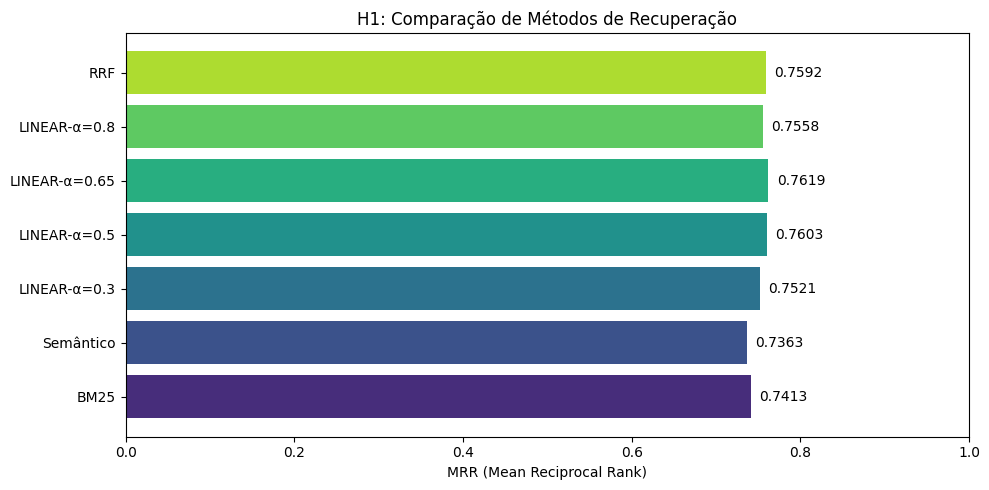

In [20]:
# === VISUALIZAÇÃO H1 ===

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
methods = list(results_h1.keys())
mrr_values = [results_h1[m]["MRR"] for m in methods]

bars = ax.barh(methods, mrr_values, color=sns.color_palette("viridis", len(methods)))
ax.set_xlabel("MRR (Mean Reciprocal Rank)")
ax.set_title("H1: Comparação de Métodos de Recuperação")
ax.set_xlim(0, 1)
for bar, val in zip(bars, mrr_values):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f"{val:.4f}", va='center')
plt.tight_layout()
plt.show()


## 6.2 H2: Impacto dos Embeddings na Classificação

> **Hipótese:** Combinar embeddings multilíngues (1024 dims, E5-large-instruct) com features engenheiradas (13 dims) supera features apenas lexicais em Macro-F1.

**Variantes testadas:** 2 conjuntos de features × 2 classificadores = 4 variantes, cada uma avaliada em 5 seeds.

| Variante | Features | Classificador | Dims |
|:---|:---|:---|:---:|
| lexical_LogReg | lex + struct + rules (todas features não-embedding) | LogisticRegression | 13 |
| lexical_LightGBM | lex + struct + rules (todas features não-embedding) | LightGBM | 13 |
| lexical+emb_LogReg | lex + struct + rules + emb | LogisticRegression | 13+EMBEDDING_DIM |
| lexical+emb_LightGBM | lex + struct + rules + emb | LightGBM (early stopping) | 13+EMBEDDING_DIM |

**Achados antecipados (TCC v3 §3.2):** Embeddings E5 adicionam **+27,9pp** de Macro-F1 (0,4533 → **0,7325**, p=0,031, Bootstrap CI [+0,268, +0,295]). F1 por classe varia de 0,69 (saudação) a 0,87 (cancelamento). Ganho com LogReg foi +25,8pp (0,3574 → 0,6158).

In [21]:
# === EXPERIMENTO H2 ===

print("=" * 70)
print("HIPÓTESE H2: EMBEDDINGS + LEXICAL vs LEXICAL-ONLY")
print("=" * 70)

# Features sets
# NOTA: X_non_emb inclui 7 lexicais + 4 estruturais + 2 regras = 13 features.
# O nome "lexical-only" é simplificação — inclui todas as features não-embedding.
X_lexical_only = X_non_emb  # 13 features (7 lex + 4 struct + 2 rules)
X_lex_emb = X_full  # 13 + EMBEDDING_DIM features

results_h2 = {}

for seed in SEEDS:
    # Split estratificado no nível da conversa
    conv_list = np.unique(conv_ids)
    conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))

    # Separar val e test
    test_val_convs = conv_list[test_val_idx]
    test_val_intents = [conv_intent_list[i] for i in test_val_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))

    train_convs = set(conv_list[train_idx])
    val_convs = set(test_val_convs[val_idx])
    test_convs_set = set(test_val_convs[test_idx])

    # Máscaras de janelas
    train_mask = np.array([c in train_convs for c in conv_ids])
    val_mask = np.array([c in val_convs for c in conv_ids])
    test_mask = np.array([c in test_convs_set for c in conv_ids])

    X_train_lex = X_lexical_only[train_mask]
    X_train_full = X_lex_emb[train_mask]
    y_train = y_labels[train_mask]

    X_val_lex = X_lexical_only[val_mask]
    X_val_full = X_lex_emb[val_mask]
    y_val = y_labels[val_mask]

    X_test_lex = X_lexical_only[test_mask]
    X_test_full = X_lex_emb[test_mask]
    y_test = y_labels[test_mask]

    # --- Variante 1: Lexical-only + LogReg ---
    lr_lex = LogisticRegression(max_iter=2000, random_state=seed)
    lr_lex.fit(X_train_lex, y_train)
    y_pred_lr_lex = lr_lex.predict(X_test_lex)
    f1_lr_lex = f1_score(y_test, y_pred_lr_lex, average='macro', zero_division=0)

    # --- Variante 2: Lexical+Emb + LogReg ---
    lr_full = LogisticRegression(max_iter=2000, random_state=seed)
    lr_full.fit(X_train_full, y_train)
    y_pred_lr_full = lr_full.predict(X_test_full)
    f1_lr_full = f1_score(y_test, y_pred_lr_full, average='macro', zero_division=0)

    # --- Variante 3: Lexical-only + LightGBM (com early stopping via validação) ---
    if HAS_LIGHTGBM:
        lgb_lex = lgb.LGBMClassifier(**BEST_LGB_PARAMS, n_estimators=500, random_state=seed, verbose=-1)
        lgb_lex.fit(X_train_lex, y_train,
                    eval_set=[(X_val_lex, y_val)],
                    callbacks=[lgb.early_stopping(15, verbose=False)])
        y_pred_lgb_lex = lgb_lex.predict(X_test_lex)
        f1_lgb_lex = f1_score(y_test, y_pred_lgb_lex, average='macro', zero_division=0)

        # --- Variante 4: Lexical+Emb + LightGBM (com early stopping via validação) ---
        lgb_full = lgb.LGBMClassifier(**BEST_LGB_PARAMS, n_estimators=500, random_state=seed, verbose=-1)
        lgb_full.fit(X_train_full, y_train,
                     eval_set=[(X_val_full, y_val)],
                     callbacks=[lgb.early_stopping(15, verbose=False)])
        y_pred_lgb_full = lgb_full.predict(X_test_full)
        f1_lgb_full = f1_score(y_test, y_pred_lgb_full, average='macro', zero_division=0)
    else:
        f1_lgb_lex = f1_lr_lex
        f1_lgb_full = f1_lr_full

    results_h2[seed] = {
        "lexical_LogReg": f1_lr_lex,
        "lexical+emb_LogReg": f1_lr_full,
        "lexical_LightGBM": f1_lgb_lex,
        "lexical+emb_LightGBM": f1_lgb_full,
    }
    print(f"  Seed {seed}: lex_LR={f1_lr_lex:.4f}, lex+emb_LR={f1_lr_full:.4f}, "
          f"lex_LGB={f1_lgb_lex:.4f}, lex+emb_LGB={f1_lgb_full:.4f}")

# Agregar resultados
print("\n" + "=" * 70)
print("RESULTADOS H2: MACRO-F1 (média ± std sobre 5 seeds)")
print("=" * 70)
df_h2 = pd.DataFrame(results_h2).T
for col in df_h2.columns:
    mean = df_h2[col].mean()
    std = df_h2[col].std()
    print(f"  {col}: {mean:.4f} ± {std:.4f}")

# Ganho
best_lex = df_h2["lexical_LightGBM"].mean()
best_full = df_h2["lexical+emb_LightGBM"].mean()
gain_pp = (best_full - best_lex) * 100
print(f"\n📈 Ganho com embeddings (LightGBM): +{gain_pp:.1f} pontos percentuais")
print(f"   ({best_lex:.4f} → {best_full:.4f})")

# F1 por classe (último seed como demonstração)
print("\n📊 F1 por Classe — lexical+emb_LightGBM (seed=999, demonstrativo)")
print(classification_report(y_test, y_pred_lgb_full if HAS_LIGHTGBM else y_pred_lr_full, zero_division=0))

HIPÓTESE H2: EMBEDDINGS + LEXICAL vs LEXICAL-ONLY
  Seed 13: lex_LR=0.3514, lex+emb_LR=0.6404, lex_LGB=0.4481, lex+emb_LGB=0.7287
  Seed 42: lex_LR=0.3447, lex+emb_LR=0.5998, lex_LGB=0.4656, lex+emb_LGB=0.7275
  Seed 123: lex_LR=0.3428, lex+emb_LR=0.5688, lex_LGB=0.4394, lex+emb_LGB=0.7063
  Seed 2024: lex_LR=0.3646, lex+emb_LR=0.6254, lex_LGB=0.4562, lex+emb_LGB=0.7291
  Seed 999: lex_LR=0.3836, lex+emb_LR=0.6672, lex_LGB=0.4572, lex+emb_LGB=0.7706

RESULTADOS H2: MACRO-F1 (média ± std sobre 5 seeds)
  lexical_LogReg: 0.3574 ± 0.0169
  lexical+emb_LogReg: 0.6203 ± 0.0378
  lexical_LightGBM: 0.4533 ± 0.0099
  lexical+emb_LightGBM: 0.7324 ± 0.0234

📈 Ganho com embeddings (LightGBM): +27.9 pontos percentuais
   (0.4533 → 0.7324)

📊 F1 por Classe — lexical+emb_LightGBM (seed=999, demonstrativo)
                 precision    recall  f1-score   support

   cancelamento       0.87      0.85      0.86       167
         compra       0.79      0.75      0.77       166
 duvida_produto       0.7

In [22]:
# === TESTE ESTATÍSTICO H2 ===
from scipy import stats as scipy_stats

print("\n📊 Teste Estatístico — Wilcoxon Signed-Rank")
print("-" * 50)

# Comparar lexical_LightGBM vs lexical+emb_LightGBM
scores_lex = [results_h2[s]["lexical_LightGBM"] for s in SEEDS]
scores_full = [results_h2[s]["lexical+emb_LightGBM"] for s in SEEDS]

diff = np.array(scores_full) - np.array(scores_lex)
nonzero = diff[diff != 0]

if len(nonzero) >= 2:
    stat, p_value = scipy_stats.wilcoxon(scores_full, scores_lex, alternative="greater")
    n = len(nonzero)
    # Rank-biserial correlation
    r_rb = (2 * stat) / (n * (n + 1) / 2) - 1

    print(f"  Comparação: lexical+emb_LightGBM vs lexical_LightGBM")
    print(f"  Estatística W: {stat:.1f}")
    print(f"  p-valor: {p_value:.6f}")
    print(f"  Significativo (α=0.05): {'SIM ✅' if p_value < 0.05 else 'NÃO ❌'}")
    print(f"  Effect size (r_rb): {r_rb:.4f} ({'grande' if abs(r_rb) > 0.5 else 'médio' if abs(r_rb) > 0.3 else 'pequeno'})")
else:
    print("  ⚠️ Pares insuficientes para teste de Wilcoxon")

# Bootstrap CI
print("\n📊 Bootstrap CI 95% (10.000 reamostras)")
n_bootstrap = 10000
rng = np.random.default_rng(42)
# NOTA: Bootstrap com N=5 — interpretar IC com cautela.
boot_diffs = []
for _ in range(n_bootstrap):
    idx = rng.integers(0, len(SEEDS), size=len(SEEDS))
    boot_lex = np.array(scores_lex)[idx]
    boot_full = np.array(scores_full)[idx]
    boot_diffs.append(np.mean(boot_full - boot_lex))

ci_lower = np.percentile(boot_diffs, 2.5)
ci_upper = np.percentile(boot_diffs, 97.5)
print(f"  Diferença média: {np.mean(diff):.4f}")
print(f"  IC 95%: [{ci_lower:.4f}, {ci_upper:.4f}]")



📊 Teste Estatístico — Wilcoxon Signed-Rank
--------------------------------------------------
  Comparação: lexical+emb_LightGBM vs lexical_LightGBM
  Estatística W: 15.0
  p-valor: 0.031250
  Significativo (α=0.05): SIM ✅
  Effect size (r_rb): 1.0000 (grande)

📊 Bootstrap CI 95% (10.000 reamostras)
  Diferença média: 0.2791
  IC 95%: [0.2661, 0.2965]


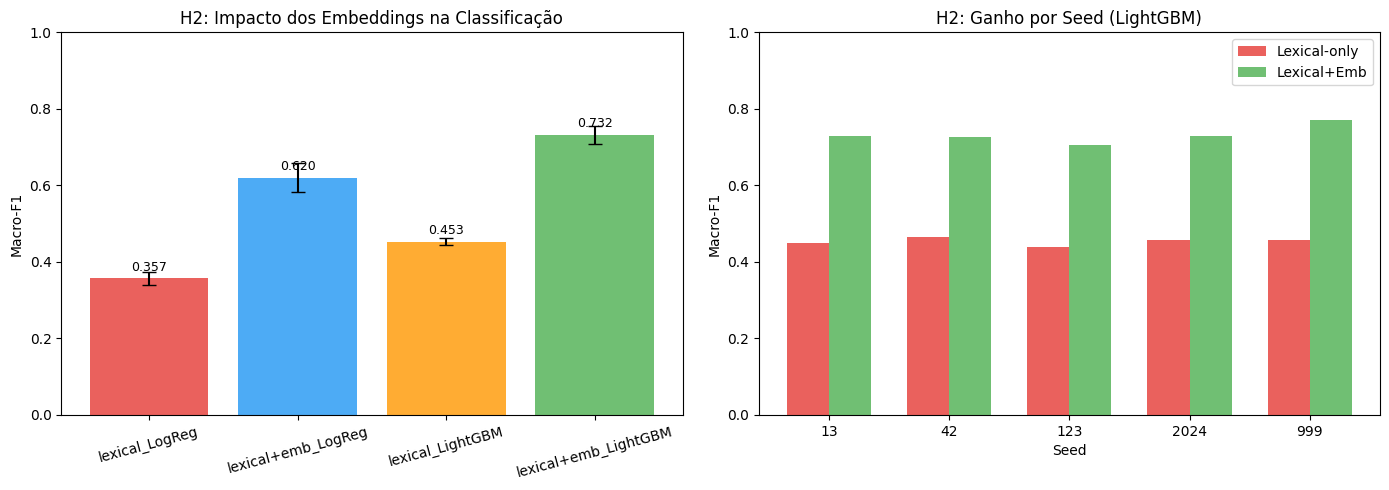

In [23]:
# === VISUALIZAÇÃO H2 ===

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Comparação das 4 variantes
variants = list(df_h2.columns)
means = [df_h2[v].mean() for v in variants]
stds = [df_h2[v].std() for v in variants]
colors = ['#E53935', '#2196F3', '#FF9800', '#4CAF50']
bars = ax1.bar(variants, means, yerr=stds, capsize=5, color=colors, alpha=0.8)
ax1.set_ylabel("Macro-F1")
ax1.set_title("H2: Impacto dos Embeddings na Classificação")
ax1.set_ylim(0, 1)
for bar, mean in zip(bars, means):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{mean:.3f}", ha='center', fontsize=9)
ax1.tick_params(axis='x', rotation=15)

# Gráfico 2: Ganho por seed (lexical vs lexical+emb, LightGBM)
seeds_labels = [str(s) for s in SEEDS]
lex_scores = [results_h2[s]["lexical_LightGBM"] for s in SEEDS]
full_scores = [results_h2[s]["lexical+emb_LightGBM"] for s in SEEDS]
x = np.arange(len(SEEDS))
w = 0.35
ax2.bar(x - w/2, lex_scores, w, label='Lexical-only', color='#E53935', alpha=0.8)
ax2.bar(x + w/2, full_scores, w, label='Lexical+Emb', color='#4CAF50', alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(seeds_labels)
ax2.set_xlabel("Seed")
ax2.set_ylabel("Macro-F1")
ax2.set_title("H2: Ganho por Seed (LightGBM)")
ax2.legend()
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 6.3 H3: Regras Determinísticas + ML

> **Hipótese:** Regras determinísticas complementam a classificação por aprendizado de máquina.

**Três estratégias comparadas:**

> **Nota metodológica:** O baseline ML-only remove as 2 features de regras base do pipeline. ML+Rules-feature adiciona todas as 10 regras como features binárias. Regras v2: negation-aware ("não quero cancelar" → rule_cancel = 0), co-occurrence (exige presença conjunta de múltiplos sinais), sem keywords genéricas (oi, obrigado, erro).

| Estratégia | Descrição |
|:---|:---|
| ML-only | LightGBM sem regras (baseline) |
| ML+Rules-gated | Regra intervém **apenas** quando ML confiança < 60% e exatamente 1 regra dispara |
| ML+Rules-feature | Matches de regras como 10 features binárias adicionais |

**Achados antecipados (TCC v3 §3.3):** Rules-as-feature Δ=+0,2pp (p=0,50, Bootstrap CI [−0,007, +0,013] inclui zero); Confidence-gating Δ=−1,4pp; Rules-only F1=0,276. Regras v2 (negation-aware, co-occurrence) **não compensaram** a redundância com embeddings E5. **H3 refutada.**


In [24]:
# === EXPERIMENTO H3 ===

print("=" * 70)
print("HIPÓTESE H3: INTEGRAÇÃO DE REGRAS")
print("=" * 70)

# Baseline sem regras: remover features de regras (índices 11-12) de X_full
IDX_NO_RULES = list(range(11)) + list(range(13, X_full.shape[1]))
X_no_rules = X_full[:, IDX_NO_RULES]  # X_full minus 2 rule features

results_h3 = {s: {} for s in SEEDS}

for seed in SEEDS:
    conv_list = np.unique(conv_ids)
    conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
    test_val_convs = conv_list[test_val_idx]
    test_val_intents = [conv_intent_list[i] for i in test_val_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))

    train_convs = set(conv_list[train_idx])
    val_convs = set(test_val_convs[val_idx])
    test_convs_set = set(test_val_convs[test_idx])

    train_mask = np.array([c in train_convs for c in conv_ids])
    val_mask = np.array([c in val_convs for c in conv_ids])
    test_mask = np.array([c in test_convs_set for c in conv_ids])

    # Dados SEM regras (baseline limpo)
    X_train_nr = X_no_rules[train_mask]
    X_val_nr = X_no_rules[val_mask]
    X_test_nr = X_no_rules[test_mask]
    y_train = y_labels[train_mask]
    y_val = y_labels[val_mask]
    y_test = y_labels[test_mask]

    # 1. ML-only (sem NENHUMA feature de regra)
    if HAS_LIGHTGBM:
        clf = lgb.LGBMClassifier(**BEST_LGB_PARAMS, n_estimators=500, random_state=seed, verbose=-1)
        clf.fit(X_train_nr, y_train,
                eval_set=[(X_val_nr, y_val)],
                callbacks=[lgb.early_stopping(15, verbose=False)])
    else:
        clf = LogisticRegression(max_iter=2000, random_state=seed)
        clf.fit(X_train_nr, y_train)
    y_pred_ml = clf.predict(X_test_nr)
    f1_ml_only = f1_score(y_test, y_pred_ml, average='macro', zero_division=0)

    # 2. Rules-only
    test_windows_h3 = [all_windows[i] for i in range(len(all_windows)) if test_mask[i]]
    majority_class = Counter(y_train.tolist()).most_common(1)[0][0]  # fallback para classes sem regra
    y_pred_rules = []
    for w in test_windows_h3:
        rule_res = evaluate_rules(w["window_text"])
        predicted = None
        for rule in RULES_V2:
            if rule_res.get(rule["rule_id"], 0.0) > 0:
                predicted = rule["intent"]
                break
        y_pred_rules.append(predicted if predicted else majority_class)
    f1_rules_only = f1_score(y_test, y_pred_rules, average='macro', zero_division=0)

    # 3. ML+Rules-confidence-gated (regra só sobrescreve quando ML tem baixa confiança)
    # Estratégia: se ML confiança < GATE_THRESHOLD E regra de alta precisão dispara → usa regra
    # Senão → usa predição ML (mais confiável na média)
    GATE_THRESHOLD = 0.60  # ML precisa estar "inseguro" para regra intervir

    # Treinar modelo para obter probabilidades
    if HAS_LIGHTGBM:
        clf_gate = lgb.LGBMClassifier(**BEST_LGB_PARAMS, n_estimators=500, random_state=seed, verbose=-1)
        clf_gate.fit(X_train_nr, y_train,
                     eval_set=[(X_val_nr, y_val)],
                     callbacks=[lgb.early_stopping(15, verbose=False)])
    else:
        clf_gate = LogisticRegression(max_iter=2000, random_state=seed)
        clf_gate.fit(X_train_nr, y_train)

    ml_proba = clf_gate.predict_proba(X_test_nr)
    ml_confidence = ml_proba.max(axis=1)
    ml_preds = clf_gate.classes_[ml_proba.argmax(axis=1)]

    y_pred_override = []
    n_gated = 0
    for i, w in enumerate(test_windows_h3):
        if ml_confidence[i] < GATE_THRESHOLD:
            # ML inseguro — consultar regras
            rule_res = evaluate_rules(w["window_text"])
            # Só usar regra se EXATAMENTE UMA classe dispara (sem ambiguidade)
            fired_intents = set()
            for rule in RULES_V2:
                if rule_res.get(rule["rule_id"], 0.0) > 0:
                    fired_intents.add(rule["intent"])
            if len(fired_intents) == 1:
                y_pred_override.append(fired_intents.pop())
                n_gated += 1
            else:
                y_pred_override.append(ml_preds[i])
        else:
            y_pred_override.append(ml_preds[i])
    f1_override = f1_score(y_test, y_pred_override, average='macro', zero_division=0)

    # 4. ML+Rules-feature (10 regras como features adicionais)
    train_windows_h3 = [all_windows[i] for i in range(len(all_windows)) if train_mask[i]]
    val_windows_h3 = [all_windows[i] for i in range(len(all_windows)) if val_mask[i]]

    rule_features_train = np.array([[evaluate_rules(w["window_text"]).get(r["rule_id"], 0.0) for r in RULES_V2] for w in train_windows_h3])
    rule_features_val = np.array([[evaluate_rules(w["window_text"]).get(r["rule_id"], 0.0) for r in RULES_V2] for w in val_windows_h3])
    rule_features_test = np.array([[evaluate_rules(w["window_text"]).get(r["rule_id"], 0.0) for r in RULES_V2] for w in test_windows_h3])

    X_train_rf = np.hstack([X_train_nr, rule_features_train])
    X_val_rf = np.hstack([X_val_nr, rule_features_val])
    X_test_rf = np.hstack([X_test_nr, rule_features_test])

    if HAS_LIGHTGBM:
        clf_rf = lgb.LGBMClassifier(**BEST_LGB_PARAMS, n_estimators=500, random_state=seed, verbose=-1)
        clf_rf.fit(X_train_rf, y_train,
                   eval_set=[(X_val_rf, y_val)],
                   callbacks=[lgb.early_stopping(15, verbose=False)])
    else:
        clf_rf = LogisticRegression(max_iter=2000, random_state=seed)
        clf_rf.fit(X_train_rf, y_train)
    y_pred_rf = clf_rf.predict(X_test_rf)
    f1_rules_feature = f1_score(y_test, y_pred_rf, average='macro', zero_division=0)

    results_h3[seed] = {
        "ML-only": f1_ml_only,
        "Rules-only": f1_rules_only,
        "ML+Rules-gated": f1_override,
        "ML+Rules-feature": f1_rules_feature,
    }
    print(f"  Seed {seed}: ML-only={f1_ml_only:.4f}, Rules={f1_rules_only:.4f}, "
          f"Gated={f1_override:.4f}, Feature={f1_rules_feature:.4f}")

# Resultados
print("\n" + "=" * 70)
print("RESULTADOS H3: MACRO-F1 (média ± std sobre 5 seeds)")
print("=" * 70)
print(f"  Nota: ML-only usa {X_no_rules.shape[1]} features (sem regras), ML+Rules-feature usa {X_train_rf.shape[1]} features")
df_h3 = pd.DataFrame(results_h3).T
for col in df_h3.columns:
    mean = df_h3[col].mean()
    std = df_h3[col].std()
    print(f"  {col}: {mean:.4f} ± {std:.4f}")

HIPÓTESE H3: INTEGRAÇÃO DE REGRAS
  Seed 13: ML-only=0.7271, Rules=0.2644, Gated=0.7176, Feature=0.7351
  Seed 42: ML-only=0.7224, Rules=0.2827, Gated=0.7123, Feature=0.7192
  Seed 123: ML-only=0.7026, Rules=0.2762, Gated=0.6933, Feature=0.7107
  Seed 2024: ML-only=0.7309, Rules=0.2769, Gated=0.7202, Feature=0.7230
  Seed 999: ML-only=0.7732, Rules=0.2791, Gated=0.7524, Feature=0.7830

RESULTADOS H3: MACRO-F1 (média ± std sobre 5 seeds)
  Nota: ML-only usa 1035 features (sem regras), ML+Rules-feature usa 1045 features
  ML-only: 0.7312 ± 0.0259
  Rules-only: 0.2759 ± 0.0069
  ML+Rules-gated: 0.7191 ± 0.0214
  ML+Rules-feature: 0.7342 ± 0.0287


In [25]:
# === TESTE ESTATÍSTICO H3 ===

print("\n📊 Testes Estatísticos H3")
print("-" * 50)

# Comparar ML+Rules-feature vs ML-only
scores_ml_only = [results_h3[s]['ML-only'] for s in SEEDS]
scores_ml_rf = [results_h3[s]['ML+Rules-feature'] for s in SEEDS]
diff_h3 = np.array(scores_ml_rf) - np.array(scores_ml_only)
nonzero_h3 = diff_h3[diff_h3 != 0]

if len(nonzero_h3) >= 2:
    stat_h3, p_h3 = scipy_stats.wilcoxon(scores_ml_rf, scores_ml_only, alternative="greater")
    n_h3 = len(nonzero_h3)
    r_rb_h3 = (2 * stat_h3) / (n_h3 * (n_h3 + 1) / 2) - 1
    print(f"  ML+Rules-feature vs ML-only:")
    print(f"  W={stat_h3:.1f}, p={p_h3:.6f}")
    print(f"  Significativo: {'SIM ✅' if p_h3 < 0.05 else 'NÃO ❌'}")
    print(f"  r_rb={r_rb_h3:.4f} ({'grande' if abs(r_rb_h3) > 0.5 else 'médio' if abs(r_rb_h3) > 0.3 else 'pequeno'})")
else:
    print("  ⚠️ Pares insuficientes para Wilcoxon (ML+Rules-feature vs ML-only)")

# Comparar ML+Rules-gated vs ML-only
scores_ml_gated = [results_h3[s]['ML+Rules-gated'] for s in SEEDS]
diff_h3b = np.array(scores_ml_gated) - np.array(scores_ml_only)
print(f"\n  ML+Rules-gated vs ML-only:")
print(f"  Diferença média: {np.mean(diff_h3b):.4f}")
if np.mean(diff_h3b) < 0:
    print("  ⚠️ Gated degrada performance — não aplicar Wilcoxon one-sided 'greater'")

# Bootstrap CI
print("\n📊 Bootstrap CI 95% — ML+Rules-feature vs ML-only")
rng_h3 = np.random.default_rng(42)
boot_h3 = []
for _ in range(10000):
    idx = rng_h3.integers(0, len(SEEDS), size=len(SEEDS))
    boot_h3.append(np.mean(np.array(scores_ml_rf)[idx] - np.array(scores_ml_only)[idx]))
print(f"  Diferença média: {np.mean(diff_h3):.4f}")
print(f"  IC 95%: [{np.percentile(boot_h3, 2.5):.4f}, {np.percentile(boot_h3, 97.5):.4f}]")

# F1 por classe (último seed como demonstração)
print("\n📊 F1 por Classe — ML+Rules-feature (seed=999, demonstrativo)")
print(classification_report(y_test, y_pred_rf, zero_division=0))



📊 Testes Estatísticos H3
--------------------------------------------------
  ML+Rules-feature vs ML-only:
  W=12.0, p=0.156250
  Significativo: NÃO ❌
  r_rb=0.6000 (grande)

  ML+Rules-gated vs ML-only:
  Diferença média: -0.0121
  ⚠️ Gated degrada performance — não aplicar Wilcoxon one-sided 'greater'

📊 Bootstrap CI 95% — ML+Rules-feature vs ML-only
  Diferença média: 0.0030
  IC 95%: [-0.0037, 0.0087]

📊 F1 por Classe — ML+Rules-feature (seed=999, demonstrativo)
                 precision    recall  f1-score   support

   cancelamento       0.88      0.84      0.86       167
         compra       0.81      0.74      0.78       166
 duvida_produto       0.74      0.79      0.76       159
 duvida_servico       0.69      0.71      0.70       158
         elogio       0.90      0.79      0.84       142
     reclamacao       0.79      0.74      0.76       159
       saudacao       0.69      0.73      0.71       161
suporte_tecnico       0.81      0.91      0.85       168

       accura

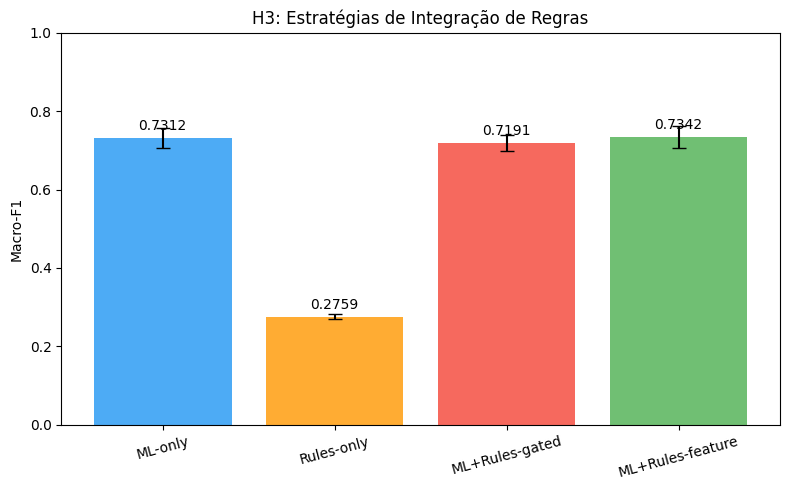

In [26]:
# === VISUALIZAÇÃO H3 ===

fig, ax = plt.subplots(figsize=(8, 5))
strategies = list(df_h3.columns)
means = [df_h3[s].mean() for s in strategies]
stds = [df_h3[s].std() for s in strategies]

colors = ['#2196F3', '#FF9800', '#F44336', '#4CAF50']
bars = ax.bar(strategies, means, yerr=stds, capsize=5, color=colors, alpha=0.8)
ax.set_ylabel("Macro-F1")
ax.set_title("H3: Estratégias de Integração de Regras")
ax.set_ylim(0, 1)
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{mean:.4f}", ha='center')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 6.4 H4: Inferência Cascateada

> **Hipótese:** A combinação de dois classificadores em cascata (LogReg → LightGBM) melhora o Macro-F1 em relação ao classificador único, explorando a complementaridade entre modelos lineares e não-lineares.

**Estratégia:** O LogReg resolve casos "fáceis" com alta confiança. Casos ambíguos são encaminhados ao LightGBM, que tem maior capacidade discriminativa.

```
Entrada ──▶ [Stage 1: LogReg] ──▶ confiança ≥ threshold? ──SIM──▶ Predição Stage 1
                                           │
                                          NÃO
                                           │
                                    [Stage 2: LightGBM] ──▶ Predição Stage 2
```

**Métricas:**
- **Macro-F1** (primária) — a cascata melhora a qualidade preditiva?
- **Tempo de inferência** (secundária) — qual o custo adicional da cascata? O trade-off justifica a complexidade?

**Variantes:** 5 thresholds de confiança × 5 seeds.

**Achados antecipados (TCC v3 §3.4):** Nenhuma variante de cascata ou ensemble supera o LightGBM isolado (**0,7325**). Ensemble-0,3/0,7: F1=0,7295 (−0,003). Cascata t=0,70: F1=0,7201 com 24% resolvido pelo Stage 1 e economia de 14% de tempo. **H4 refutada** — cascata LogReg→LightGBM não possui complementaridade porque ambos operam sobre as mesmas features E5.

In [27]:
# === EXPERIMENTO H4 ===

print("=" * 70)
print("HIPÓTESE H4: INFERÊNCIA CASCATEADA (F1 + TEMPO)")
print("=" * 70)

CASCADE_THRESHOLDS = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95]
results_h4 = {s: {} for s in SEEDS}
timing_h4 = {s: {} for s in SEEDS}
cascade_stats = {s: {} for s in SEEDS}

for seed in SEEDS:
    conv_list = np.unique(conv_ids)
    conv_intent_list = [intents_per_conv.get(c, 'outros') for c in conv_list]

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
    test_val_convs = conv_list[test_val_idx]
    test_val_intents = [conv_intent_list[i] for i in test_val_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))

    train_convs = set(conv_list[train_idx])
    val_convs = set(test_val_convs[val_idx])
    test_convs_set = set(test_val_convs[test_idx])

    train_mask = np.array([c in train_convs for c in conv_ids])
    val_mask = np.array([c in val_convs for c in conv_ids])
    test_mask = np.array([c in test_convs_set for c in conv_ids])

    X_train = X_full[train_mask]
    X_val = X_full[val_mask]
    y_train = y_labels[train_mask]
    y_val = y_labels[val_mask]
    X_test = X_full[test_mask]
    y_test = y_labels[test_mask]

    # Stage 1: LogReg
    stage1 = LogisticRegression(max_iter=2000, random_state=seed)
    stage1.fit(X_train, y_train)

    # Stage 2: LightGBM (otimizado)
    if HAS_LIGHTGBM:
        stage2 = lgb.LGBMClassifier(**BEST_LGB_PARAMS, n_estimators=300, random_state=seed, verbose=-1)
        stage2.fit(X_train, y_train,
                   eval_set=[(X_val, y_val)],
                   callbacks=[lgb.early_stopping(10, verbose=False)])
    else:
        stage2 = LogisticRegression(max_iter=2000, random_state=seed, C=10.0)
        stage2.fit(X_train, y_train)

    # === Baseline: LightGBM sozinho ===
    t0 = time.perf_counter()
    y_pred_uniform = stage2.predict(X_test)
    time_uniform = time.perf_counter() - t0
    f1_uniform = f1_score(y_test, y_pred_uniform, average='macro', zero_division=0)
    results_h4[seed]['LightGBM-only'] = f1_uniform
    timing_h4[seed]['LightGBM-only'] = time_uniform

    # === Baseline: LogReg sozinho ===
    t0 = time.perf_counter()
    y_pred_lr = stage1.predict(X_test)
    time_lr = time.perf_counter() - t0
    f1_lr = f1_score(y_test, y_pred_lr, average='macro', zero_division=0)
    results_h4[seed]['LogReg-only'] = f1_lr
    timing_h4[seed]['LogReg-only'] = time_lr

    # Stage 1 probabilidades (timed para medição real da cascata)
    t0_s1 = time.perf_counter()
    stage1_proba = stage1.predict_proba(X_test)
    time_stage1 = time.perf_counter() - t0_s1
    stage1_confidence = stage1_proba.max(axis=1)
    stage1_preds = stage1.classes_[stage1_proba.argmax(axis=1)]

    # Stage 2 probabilidades completas (para ensemble — timed separadamente)
    t0_s2_full = time.perf_counter()
    stage2_proba = stage2.predict_proba(X_test)
    time_stage2_full = time.perf_counter() - t0_s2_full

    # Validar que ambos os modelos usam a mesma ordenação de classes (Fix 8)
    assert np.array_equal(stage1.classes_, stage2.classes_), \
        f"Classes divergem: Stage1={stage1.classes_} vs Stage2={stage2.classes_}"

    # === Cascata: Stage 1 decide ou delega ao Stage 2 ===
    # NOTA: Stage 2 roda APENAS nas amostras incertas (cenário real de deploy)
    for threshold in CASCADE_THRESHOLDS:
        uncertain_mask = stage1_confidence < threshold
        n_stage1_resolved = int((~uncertain_mask).sum())
        n_stage2_needed = int(uncertain_mask.sum())

        # Stage 2 parcial: apenas amostras incertas (timed)
        t0_s2_partial = time.perf_counter()
        cascade_preds = np.array(stage1_preds, copy=True)
        if n_stage2_needed > 0:
            s2_partial = stage2.predict(X_test[uncertain_mask])
            cascade_preds[uncertain_mask] = s2_partial
        time_stage2_partial = time.perf_counter() - t0_s2_partial

        f1_cascade = f1_score(y_test, cascade_preds, average='macro', zero_division=0)
        stage1_pct = n_stage1_resolved / len(X_test) * 100

        key = f'cascade_t{threshold:.2f}'
        results_h4[seed][key] = f1_cascade
        timing_h4[seed][key] = time_stage1 + time_stage2_partial  # Stage 1 completo + Stage 2 parcial
        cascade_stats[seed][key] = {
            'stage1_resolved': n_stage1_resolved,
            'stage2_needed': n_stage2_needed,
            'stage1_pct': stage1_pct,
        }

    # === Ensemble: média das probabilidades dos dois modelos ===
    t0 = time.perf_counter()
    ensemble_proba = 0.5 * stage1_proba + 0.5 * stage2_proba
    ensemble_preds = stage1.classes_[ensemble_proba.argmax(axis=1)]
    time_fusion = time.perf_counter() - t0
    time_ensemble = time_stage1 + time_stage2_full + time_fusion
    f1_ensemble = f1_score(y_test, ensemble_preds, average='macro', zero_division=0)
    results_h4[seed]['Ensemble-avg'] = f1_ensemble
    timing_h4[seed]['Ensemble-avg'] = time_ensemble

    # === Ensemble ponderado: peso maior para LightGBM ===
    t0 = time.perf_counter()
    ensemble_w_proba = 0.3 * stage1_proba + 0.7 * stage2_proba
    ensemble_w_preds = stage1.classes_[ensemble_w_proba.argmax(axis=1)]
    time_fusion_w = time.perf_counter() - t0
    time_ensemble_w = time_stage1 + time_stage2_full + time_fusion_w
    f1_ensemble_w = f1_score(y_test, ensemble_w_preds, average='macro', zero_division=0)
    results_h4[seed]['Ensemble-0.3/0.7'] = f1_ensemble_w
    timing_h4[seed]['Ensemble-0.3/0.7'] = time_ensemble_w

    print(f"  Seed {seed}: LGB={f1_uniform:.4f}, LR={f1_lr:.4f}, "
          f"Cascade-0.70={results_h4[seed].get('cascade_t0.70',0):.4f}, "
          f"Ensemble={f1_ensemble:.4f}, Ens-0.3/0.7={f1_ensemble_w:.4f}")

# === Resultados ===
print("\n" + "=" * 70)
print("RESULTADOS H4: MACRO-F1 (média ± std sobre 5 seeds)")
print("=" * 70)

df_h4 = pd.DataFrame(results_h4).T
df_timing = pd.DataFrame(timing_h4).T

# Ordenar por F1 médio
col_order = df_h4.mean().sort_values(ascending=False).index
for col in col_order:
    mean_f1 = df_h4[col].mean()
    std_f1 = df_h4[col].std()
    mean_time = df_timing[col].mean() * 1000
    delta_f1 = mean_f1 - df_h4['LightGBM-only'].mean()
    marker = " ← baseline" if col == 'LightGBM-only' else ""
    print(f"  {col:20s}: F1={mean_f1:.4f} ± {std_f1:.4f}  Δ={delta_f1:+.4f}  tempo={mean_time:.1f}ms{marker}")

# Teste estatístico: melhor método vs LightGBM-only
print("\n📊 Teste Estatístico H4 — Wilcoxon Signed-Rank")
print("-" * 50)

best_col = df_h4.mean().idxmax()
if best_col != 'LightGBM-only':
    scores_best = [results_h4[s][best_col] for s in SEEDS]
    scores_base = [results_h4[s]['LightGBM-only'] for s in SEEDS]
    diff_h4 = np.array(scores_best) - np.array(scores_base)
    nonzero = diff_h4[diff_h4 != 0]

    print(f"  Comparação: {best_col} vs LightGBM-only")
    print(f"  Diferença média F1: {np.mean(diff_h4):+.4f}")

    if len(nonzero) >= 2:
        stat_h4, p_h4 = scipy_stats.wilcoxon(scores_best, scores_base, alternative="greater")
        n_h4 = len(nonzero)
        r_rb_h4 = (2 * stat_h4) / (n_h4 * (n_h4 + 1) / 2) - 1
        print(f"  W={stat_h4:.1f}, p={p_h4:.6f}")
        print(f"  Significativo: {'SIM ✅' if p_h4 < 0.05 else 'NÃO ❌'}")
        print(f"  r_rb={r_rb_h4:.4f}")

    # Bootstrap CI
    rng_h4 = np.random.default_rng(42)
    boot_h4 = []
    for _ in range(10000):
        idx = rng_h4.integers(0, len(SEEDS), size=len(SEEDS))
        boot_h4.append(np.mean(np.array(scores_best)[idx] - np.array(scores_base)[idx]))
    print(f"  Bootstrap CI 95%: [{np.percentile(boot_h4, 2.5):.4f}, {np.percentile(boot_h4, 97.5):.4f}]")
else:
    print(f"  LightGBM-only é o melhor método — cascata não melhora F1")

# Custo adicional
print(f"\n📊 Análise de Custo (tempo)")
time_base = df_timing['LightGBM-only'].mean() * 1000
for col in col_order:
    if col == 'LightGBM-only':
        continue
    t = df_timing[col].mean() * 1000
    overhead = (t / time_base - 1) * 100 if time_base > 0 else 0
    f1_gain = (df_h4[col].mean() - df_h4['LightGBM-only'].mean())
    print(f"  {col:20s}: {t:.1f}ms ({overhead:+.0f}% vs baseline), ΔF1={f1_gain:+.4f}")

# Cascata stats
print(f"\n📊 Proporção resolvida pelo Stage 1 (LogReg):")
for t in CASCADE_THRESHOLDS:
    key = f'cascade_t{t:.2f}'
    pcts = [cascade_stats[s][key]['stage1_pct'] for s in SEEDS]
    print(f"  threshold={t:.2f}: {np.mean(pcts):.1f}% resolvido pelo Stage 1 "
          f"({100-np.mean(pcts):.1f}% vai ao Stage 2)")

HIPÓTESE H4: INFERÊNCIA CASCATEADA (F1 + TEMPO)
  Seed 13: LGB=0.7287, LR=0.6404, Cascade-0.70=0.7189, Ensemble=0.7171, Ens-0.3/0.7=0.7259
  Seed 42: LGB=0.7275, LR=0.5998, Cascade-0.70=0.7178, Ensemble=0.7153, Ens-0.3/0.7=0.7269
  Seed 123: LGB=0.7063, LR=0.5688, Cascade-0.70=0.6889, Ensemble=0.6858, Ens-0.3/0.7=0.7000
  Seed 2024: LGB=0.7216, LR=0.6254, Cascade-0.70=0.7127, Ensemble=0.7167, Ens-0.3/0.7=0.7207
  Seed 999: LGB=0.7650, LR=0.6672, Cascade-0.70=0.7528, Ensemble=0.7592, Ens-0.3/0.7=0.7668

RESULTADOS H4: MACRO-F1 (média ± std sobre 5 seeds)
  LightGBM-only       : F1=0.7298 ± 0.0216  Δ=+0.0000  tempo=3.6ms ← baseline
  Ensemble-0.3/0.7    : F1=0.7281 ± 0.0242  Δ=-0.0017  tempo=9.4ms
  cascade_t0.95       : F1=0.7262 ± 0.0204  Δ=-0.0036  tempo=9.8ms
  cascade_t0.90       : F1=0.7247 ± 0.0204  Δ=-0.0051  tempo=9.9ms
  cascade_t0.80       : F1=0.7218 ± 0.0204  Δ=-0.0080  tempo=10.7ms
  Ensemble-avg        : F1=0.7188 ± 0.0261  Δ=-0.0110  tempo=9.4ms
  cascade_t0.70       : F1

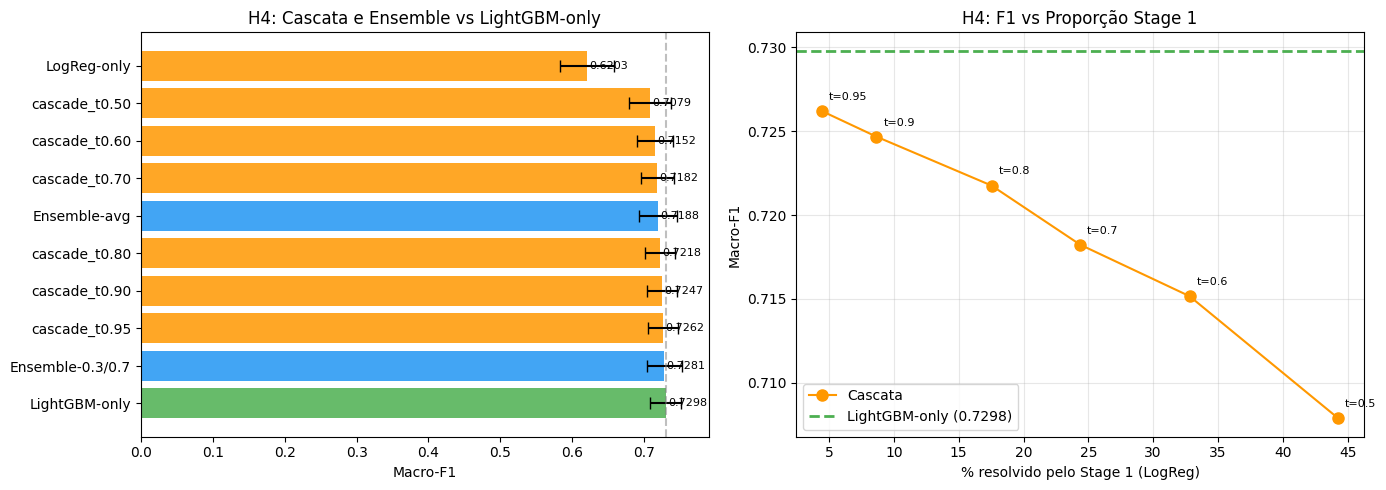


📊 Resumo H4: F1 × Tempo × Proporção Stage 1
---------------------------------------------------------------------------
                Método    Macro-F1       ΔF1     Tempo   Stage1%
---------------------------------------------------------------------------
         LightGBM-only      0.7298   +0.0000      3.6ms        0% ←
      Ensemble-0.3/0.7      0.7281   -0.0017      9.4ms         —
         cascade_t0.95      0.7262   -0.0036      9.8ms        4%
         cascade_t0.90      0.7247   -0.0051      9.9ms        9%
         cascade_t0.80      0.7218   -0.0080     10.7ms       18%
          Ensemble-avg      0.7188   -0.0110      9.4ms         —
         cascade_t0.70      0.7182   -0.0116     10.2ms       24%
         cascade_t0.60      0.7152   -0.0146      9.3ms       33%
         cascade_t0.50      0.7079   -0.0219      9.5ms       44%
           LogReg-only      0.6203   -0.1095      4.8ms      100%


In [28]:
# === VISUALIZAÇÃO H4 ===

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: F1 por método (barras)
methods = list(df_h4.mean().sort_values(ascending=False).index)
means = [df_h4[m].mean() for m in methods]
stds = [df_h4[m].std() for m in methods]
colors = ['#4CAF50' if m == 'LightGBM-only' else '#2196F3' if 'Ensemble' in m else '#FF9800' for m in methods]

bars = ax1.barh(methods, means, xerr=stds, capsize=4, color=colors, alpha=0.85)
ax1.axvline(x=df_h4['LightGBM-only'].mean(), color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel("Macro-F1")
ax1.set_title("H4: Cascata e Ensemble vs LightGBM-only")
for bar, mean in zip(bars, means):
    ax1.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
             f"{mean:.4f}", va='center', fontsize=8)

# Gráfico 2: F1 vs % resolvido pelo Stage 1
cascade_cols = [c for c in df_h4.columns if 'cascade' in c]
f1_vals = [df_h4[c].mean() for c in cascade_cols]
stage1_pcts = []
for c in cascade_cols:
    pcts = [cascade_stats[s][c]['stage1_pct'] for s in SEEDS]
    stage1_pcts.append(np.mean(pcts))

ax2.plot(stage1_pcts, f1_vals, 'o-', color='#FF9800', markersize=8, label='Cascata')
ax2.axhline(df_h4['LightGBM-only'].mean(), color='#4CAF50', linestyle='--',
            linewidth=2, label=f'LightGBM-only ({df_h4["LightGBM-only"].mean():.4f})')
for pct, f1, t in zip(stage1_pcts, f1_vals, CASCADE_THRESHOLDS):
    ax2.annotate(f't={t}', (pct, f1), textcoords="offset points",
                 xytext=(5, 8), fontsize=8)
ax2.set_xlabel("% resolvido pelo Stage 1 (LogReg)")
ax2.set_ylabel("Macro-F1")
ax2.set_title("H4: F1 vs Proporção Stage 1")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Tabela resumo
print("\n📊 Resumo H4: F1 × Tempo × Proporção Stage 1")
print("-" * 75)
print(f"  {'Método':>20s}  {'Macro-F1':>10s}  {'ΔF1':>8s}  {'Tempo':>8s}  {'Stage1%':>8s}")
print("-" * 75)
f1_base = df_h4['LightGBM-only'].mean()
for col in df_h4.mean().sort_values(ascending=False).index:
    f1 = df_h4[col].mean()
    delta = f1 - f1_base
    t = df_timing[col].mean() * 1000
    if 'cascade' in col:
        pcts = [cascade_stats[s][col]['stage1_pct'] for s in SEEDS]
        s1 = f"{np.mean(pcts):.0f}%"
    elif col == 'LogReg-only':
        s1 = "100%"
    elif col == 'LightGBM-only':
        s1 = "0%"
    else:
        s1 = "—"
    marker = " ←" if col == 'LightGBM-only' else ""
    print(f"  {col:>20s}  {f1:>10.4f}  {delta:>+8.4f}  {t:>7.1f}ms  {s1:>8s}{marker}")

## 6.5 Estudo de Ablação

Quantificamos a contribuição marginal de cada família de features removendo-as uma a uma do modelo completo (1037 dims). Isso identifica quais componentes são essenciais e quais são redundantes.

| Configuração | Features | O que mede |
|:---|:---:|:---|
| Full (13+EMBEDDING_DIM) | todas | Modelo completo (baseline) |
| −Embeddings (13) | lex + struct + rules | Contribuição dos embeddings (E5-1024d) |
| −Lexicais (390) | struct + rules + emb | Contribuição das features lexicais |
| −Regras base (395) | lex + struct + emb | Contribuição das 2 regras do pipeline base (cancel, complaint) |
| −Estruturais (393) | lex + rules + emb | Contribuição das features estruturais |
| Embedding-only (1024) | emb | Embeddings sozinhos |
| Lex+Struct (11) | lex + struct (sem regras) | Features manuais sozinhas |

**Achados antecipados (TCC v3 §3.5):** Embeddings E5 são responsáveis por **98,5%** da performance (Embedding-only F1=0,7217 vs Full 0,7325, Δ=−0,011). Remover features estruturais **melhora F1 (+0,002)**, indicando que `is_customer`/`is_agent`/`turn_count` são ruído com E5. Features lexicais contribuem +1,3pp; regras base contribuem +0,3pp.

In [29]:
# === ABLAÇÃO ===

print("=" * 70)
print("ESTUDO DE ABLAÇÃO")
print("=" * 70)

# Índices de features
IDX_LEXICAL = list(range(7))          # 0-6
IDX_STRUCTURAL = list(range(7, 11))   # 7-10
IDX_RULES = list(range(11, 13))       # 11-12
IDX_EMBEDDING = list(range(13, 13 + EMBEDDING_DIM))  # 13 to 13+EMBEDDING_DIM-1

ablation_configs = {
    f"Full ({13 + EMBEDDING_DIM})": list(range(13 + EMBEDDING_DIM)),
    "-Embeddings (13)": IDX_LEXICAL + IDX_STRUCTURAL + IDX_RULES,
    f"-Lexicais ({13 + EMBEDDING_DIM - 7})": IDX_STRUCTURAL + IDX_RULES + IDX_EMBEDDING,
    f"-Regras base ({13 + EMBEDDING_DIM - 2})": IDX_LEXICAL + IDX_STRUCTURAL + IDX_EMBEDDING,
    f"-Estruturais ({13 + EMBEDDING_DIM - 4})": IDX_LEXICAL + IDX_RULES + IDX_EMBEDDING,
    f"Embedding-only ({EMBEDDING_DIM})": IDX_EMBEDDING,
    "Lex+Struct (11)": IDX_LEXICAL + IDX_STRUCTURAL,
}

results_ablation = {}

for config_name, feature_indices in ablation_configs.items():
    f1_scores_per_seed = []

    for seed in SEEDS:
        conv_list = np.unique(conv_ids)
        conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
        train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
        test_val_convs = conv_list[test_val_idx]
        test_val_intents = [conv_intent_list[i] for i in test_val_idx]
        sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
        val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))

        train_convs = set(conv_list[train_idx])
        val_convs = set(test_val_convs[val_idx])
        test_convs_set = set(test_val_convs[test_idx])

        train_mask = np.array([c in train_convs for c in conv_ids])
        val_mask = np.array([c in val_convs for c in conv_ids])
        test_mask = np.array([c in test_convs_set for c in conv_ids])

        X_train_ab = X_full[train_mask][:, feature_indices]
        X_val_ab = X_full[val_mask][:, feature_indices]
        y_train_ab = y_labels[train_mask]
        y_val_ab = y_labels[val_mask]
        X_test_ab = X_full[test_mask][:, feature_indices]
        y_test_ab = y_labels[test_mask]

        if HAS_LIGHTGBM:
            clf = lgb.LGBMClassifier(**BEST_LGB_PARAMS, n_estimators=500, random_state=seed, verbose=-1)
            clf.fit(X_train_ab, y_train_ab,
                    eval_set=[(X_val_ab, y_val_ab)],
                    callbacks=[lgb.early_stopping(15, verbose=False)])
        else:
            clf = LogisticRegression(max_iter=2000, random_state=seed)
            clf.fit(X_train_ab, y_train_ab)
        y_pred = clf.predict(X_test_ab)
        f1 = f1_score(y_test_ab, y_pred, average='macro', zero_division=0)
        f1_scores_per_seed.append(f1)

    results_ablation[config_name] = {
        "mean_f1": np.mean(f1_scores_per_seed),
        "std_f1": np.std(f1_scores_per_seed),
        "n_features": len(feature_indices),
    }
    print(f"  {config_name}: F1={np.mean(f1_scores_per_seed):.4f} ± {np.std(f1_scores_per_seed):.4f}")

# Tabela
print("\n" + "=" * 70)
df_ablation = pd.DataFrame(results_ablation).T
print(df_ablation.to_string())

ESTUDO DE ABLAÇÃO
  Full (1037): F1=0.7324 ± 0.0209
  -Embeddings (13): F1=0.4533 ± 0.0089
  -Lexicais (1030): F1=0.7246 ± 0.0183
  -Regras base (1035): F1=0.7312 ± 0.0231
  -Estruturais (1033): F1=0.7321 ± 0.0221
  Embedding-only (1024): F1=0.7252 ± 0.0197
  Lex+Struct (11): F1=0.3850 ± 0.0097

                        mean_f1    std_f1  n_features
Full (1037)            0.732434  0.020939      1037.0
-Embeddings (13)       0.453303  0.008897        13.0
-Lexicais (1030)       0.724619  0.018272      1030.0
-Regras base (1035)    0.731225  0.023138      1035.0
-Estruturais (1033)    0.732124  0.022085      1033.0
Embedding-only (1024)  0.725165  0.019703      1024.0
Lex+Struct (11)        0.384992  0.009722        11.0


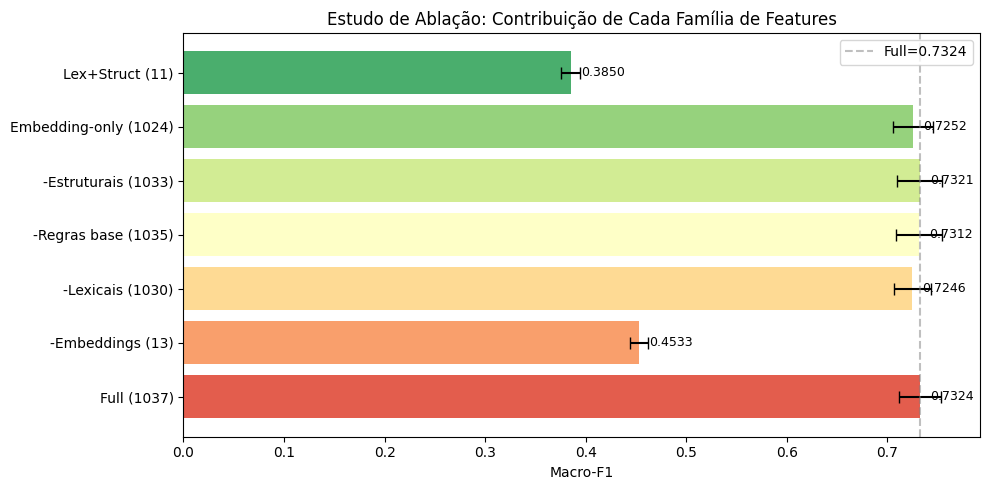

In [30]:
# === VISUALIZAÇÃO ABLAÇÃO ===

fig, ax = plt.subplots(figsize=(10, 5))
configs = list(results_ablation.keys())
means = [results_ablation[c]["mean_f1"] for c in configs]
stds = [results_ablation[c]["std_f1"] for c in configs]

colors = sns.color_palette("RdYlGn", len(configs))
bars = ax.barh(configs, means, xerr=stds, capsize=4, color=colors, alpha=0.85)
ax.set_xlabel("Macro-F1")
ax.set_title("Estudo de Ablação: Contribuição de Cada Família de Features")
ax.axvline(x=means[0], color='gray', linestyle='--', alpha=0.5, label=f'Full={means[0]:.4f}')
ax.legend()
for bar, mean in zip(bars, means):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f"{mean:.4f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()


## 6.6 Agregação Janela → Conversa

Agrega predições no nível da janela para o nível da conversa usando **média das probabilidades** (conforme descrito no pipeline, Stage 2 §6).

Isso permite avaliar a performance do classificador na granularidade que importa ao usuário final: a conversa inteira, não janelas individuais.

| Nível | Unidade | Método |
|:---|:---|:---|
| Janela | Segmento de 5 turnos | Predição direta do LightGBM |
| Conversa | Interação completa | Média das probabilidades das janelas → argmax |

**Achados antecipados (TCC v3 §3.6):** A agregação por média de probabilidades eleva o Macro-F1 de 0,7325 (janela) para **0,8303** (conversa), ganho de **+9,8pp**. No nível da conversa, todas as classes atingem F1 ≥ 0,81: cancelamento 0,99, suporte técnico 0,90, elogio 0,89, dúvida de serviço 0,88, compra 0,84, dúvida de produto 0,83, saudação 0,82, reclamação 0,81.

In [31]:
# === AGREGAÇÃO JANELA → CONVERSA ===
# Método: média das probabilidades preditas por janela, decisão por argmax.

print("=" * 70)
print("AGREGAÇÃO JANELA → CONVERSA (média de probabilidades)")
print("=" * 70)

agg_results = {}

for seed in SEEDS:
    conv_list = np.unique(conv_ids)
    conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
    test_val_convs = conv_list[test_val_idx]
    test_val_intents = [conv_intent_list[i] for i in test_val_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))

    train_convs = set(conv_list[train_idx])
    val_convs = set(test_val_convs[val_idx])
    test_convs_set = set(test_val_convs[test_idx])

    train_mask = np.array([c in train_convs for c in conv_ids])
    val_mask = np.array([c in val_convs for c in conv_ids])
    test_mask = np.array([c in test_convs_set for c in conv_ids])

    # Treinar modelo completo (13 + EMBEDDING_DIM features)
    if HAS_LIGHTGBM:
        clf_agg = lgb.LGBMClassifier(**BEST_LGB_PARAMS, n_estimators=500, random_state=seed, verbose=-1)
        clf_agg.fit(X_full[train_mask], y_labels[train_mask],
                    eval_set=[(X_full[val_mask], y_labels[val_mask])],
                    callbacks=[lgb.early_stopping(15, verbose=False)])
    else:
        clf_agg = LogisticRegression(max_iter=2000, random_state=seed)
        clf_agg.fit(X_full[train_mask], y_labels[train_mask])

    # Predições no nível da janela
    proba_windows = clf_agg.predict_proba(X_full[test_mask])
    pred_windows = clf_agg.predict(X_full[test_mask])
    classes = clf_agg.classes_

    # F1 no nível da janela
    f1_window = f1_score(y_labels[test_mask], pred_windows, average='macro', zero_division=0)

    # Agregar por conversa: média das probabilidades
    test_conv_ids = conv_ids[test_mask]
    conv_proba = {}
    conv_true = {}

    for i, cid in enumerate(test_conv_ids):
        if cid not in conv_proba:
            conv_proba[cid] = []
            conv_true[cid] = y_labels[test_mask][i]
        conv_proba[cid].append(proba_windows[i])

    y_conv_true = []
    y_conv_pred = []
    for cid in conv_proba:
        mean_p = np.mean(conv_proba[cid], axis=0)
        y_conv_pred.append(classes[np.argmax(mean_p)])
        y_conv_true.append(conv_true[cid])

    f1_conv = f1_score(y_conv_true, y_conv_pred, average='macro', zero_division=0)

    agg_results[seed] = {
        "f1_window": f1_window,
        "f1_conversation": f1_conv,
        "n_windows": int(test_mask.sum()),
        "n_conversations": len(conv_proba),
    }
    print(f"  Seed {seed}: F1_janela={f1_window:.4f}, F1_conversa={f1_conv:.4f} "
          f"({len(conv_proba)} conversas, {int(test_mask.sum())} janelas)")

# Resumo
print("\n" + "=" * 70)
f1w_mean = np.mean([r["f1_window"] for r in agg_results.values()])
f1c_mean = np.mean([r["f1_conversation"] for r in agg_results.values()])
f1w_std = np.std([r["f1_window"] for r in agg_results.values()])
f1c_std = np.std([r["f1_conversation"] for r in agg_results.values()])
delta = f1c_mean - f1w_mean

print(f"  Macro-F1 (janela):    {f1w_mean:.4f} ± {f1w_std:.4f}")
print(f"  Macro-F1 (conversa):  {f1c_mean:.4f} ± {f1c_std:.4f}")
print(f"  Δ F1 (conversa - janela): {delta:+.4f}")

if delta > 0:
    print(f"\n  ✅ Agregação por média de probabilidades melhora a predição no nível da conversa")
else:
    print(f"\n  ⚠️ Agregação não melhorou — possível efeito de janelas ruidosas")

# F1 por classe (último seed)
print(f"\n📊 F1 por Classe — nível conversa (seed={SEEDS[-1]})")
print(classification_report(y_conv_true, y_conv_pred, zero_division=0))

AGREGAÇÃO JANELA → CONVERSA (média de probabilidades)
  Seed 13: F1_janela=0.7287, F1_conversa=0.8217 (318 conversas, 1296 janelas)
  Seed 42: F1_janela=0.7275, F1_conversa=0.8273 (318 conversas, 1279 janelas)
  Seed 123: F1_janela=0.7063, F1_conversa=0.7994 (318 conversas, 1291 janelas)
  Seed 2024: F1_janela=0.7291, F1_conversa=0.8217 (318 conversas, 1295 janelas)
  Seed 999: F1_janela=0.7706, F1_conversa=0.8798 (318 conversas, 1280 janelas)

  Macro-F1 (janela):    0.7324 ± 0.0209
  Macro-F1 (conversa):  0.8300 ± 0.0267
  Δ F1 (conversa - janela): +0.0976

  ✅ Agregação por média de probabilidades melhora a predição no nível da conversa

📊 F1 por Classe — nível conversa (seed=999)
                 precision    recall  f1-score   support

   cancelamento       0.98      1.00      0.99        40
         compra       0.87      0.82      0.85        40
 duvida_produto       0.81      0.88      0.84        40
 duvida_servico       0.94      0.82      0.88        39
         elogio      

## 6.7 Análise Complementar

### Avaliação em dados originais vs sintéticos
O corpus contém 676 conversas originais e 1.444 sintéticas. Reportar F1 separadamente demonstra que o modelo generaliza para dados reais, não apenas para padrões aprendidos das sintéticas.

### Matriz de confusão
Visualiza quais classes o modelo confunde com mais frequência.

### Importância de features
Identifica quais das 1037 features o LightGBM considera mais relevantes para a classificação.

In [32]:
# === F1 EM DADOS ORIGINAIS vs SINTÉTICOS ===

print("=" * 70)
print("AVALIAÇÃO: DADOS ORIGINAIS vs SINTÉTICOS")
print("=" * 70)

# Mapear conv_id → _synthetic
conv_is_synthetic = {}
for _, row in df_original.iterrows():
    conv_is_synthetic[row['conv_id']] = bool(row.get('_synthetic', False))

results_split = {s: {} for s in SEEDS}

for seed in SEEDS:
    conv_list = np.unique(conv_ids)
    conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
    test_val_convs = conv_list[test_val_idx]
    test_val_intents = [conv_intent_list[i] for i in test_val_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))

    train_convs = set(conv_list[train_idx])
    val_convs = set(test_val_convs[val_idx])
    test_convs_set = set(test_val_convs[test_idx])

    train_mask = np.array([c in train_convs for c in conv_ids])
    val_mask = np.array([c in val_convs for c in conv_ids])
    test_mask = np.array([c in test_convs_set for c in conv_ids])

    # Treinar modelo
    if HAS_LIGHTGBM:
        clf_eval = lgb.LGBMClassifier(**BEST_LGB_PARAMS, n_estimators=300, random_state=seed, verbose=-1)
        clf_eval.fit(X_full[train_mask], y_labels[train_mask],
                     eval_set=[(X_full[val_mask], y_labels[val_mask])],
                     callbacks=[lgb.early_stopping(10, verbose=False)])
    else:
        clf_eval = LogisticRegression(max_iter=2000, random_state=seed)
        clf_eval.fit(X_full[train_mask], y_labels[train_mask])

    y_pred_all = clf_eval.predict(X_full[test_mask])
    test_conv_ids_arr = conv_ids[test_mask]
    y_test_arr = y_labels[test_mask]

    # F1 total
    f1_all = f1_score(y_test_arr, y_pred_all, average='macro', zero_division=0)

    # Separar janelas por origem
    orig_mask_test = np.array([not conv_is_synthetic.get(c, False) for c in test_conv_ids_arr])
    syn_mask_test = ~orig_mask_test

    f1_orig = f1_score(y_test_arr[orig_mask_test], y_pred_all[orig_mask_test],
                       average='macro', zero_division=0) if orig_mask_test.sum() > 0 else 0
    f1_syn = f1_score(y_test_arr[syn_mask_test], y_pred_all[syn_mask_test],
                      average='macro', zero_division=0) if syn_mask_test.sum() > 0 else 0

    results_split[seed] = {
        'all': f1_all,
        'original': f1_orig,
        'synthetic': f1_syn,
        'n_orig': int(orig_mask_test.sum()),
        'n_syn': int(syn_mask_test.sum()),
    }

# Resultados
print(f"\n📊 Macro-F1 por origem (média ± std sobre 5 seeds):")
for key, label in [('all', 'Todos'), ('original', 'Originais'), ('synthetic', 'Sintéticas')]:
    scores = [results_split[s][key] for s in SEEDS]
    n_samples = [results_split[s].get(f'n_{key[:4]}', results_split[s].get(f'n_{key[:3]}', '?')) for s in SEEDS]
    print(f"   {label:12s}: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

# Detalhe por seed
print(f"\n📊 Detalhe por seed:")
print(f"   {'Seed':>6s}  {'Todos':>8s}  {'Originais':>10s}  {'Sintéticas':>11s}  {'N_orig':>7s}  {'N_syn':>6s}")
for seed in SEEDS:
    r = results_split[seed]
    print(f"   {seed:>6d}  {r['all']:>8.4f}  {r['original']:>10.4f}  {r['synthetic']:>11.4f}  {r['n_orig']:>7d}  {r['n_syn']:>6d}")

delta = np.mean([results_split[s]['original'] for s in SEEDS]) - np.mean([results_split[s]['synthetic'] for s in SEEDS])
print(f"\n   Δ (originais - sintéticas): {delta:+.4f}")
if abs(delta) < 0.05:
    print("   ✅ Performance similar — modelo generaliza bem para ambos")
elif delta > 0:
    print("   ⚠️ Modelo performa melhor em originais — sintéticas podem ter padrões diferentes")
else:
    print("   ⚠️ Modelo performa melhor em sintéticas — possível viés nos dados gerados")

AVALIAÇÃO: DADOS ORIGINAIS vs SINTÉTICOS

📊 Macro-F1 por origem (média ± std sobre 5 seeds):
   Todos       : 0.7298 ± 0.0193
   Originais   : 0.5757 ± 0.0156
   Sintéticas  : 0.7951 ± 0.0242

📊 Detalhe por seed:
     Seed     Todos   Originais   Sintéticas   N_orig   N_syn
       13    0.7287      0.5588       0.7968      385     911
       42    0.7275      0.5890       0.7795      343     936
      123    0.7063      0.5760       0.7723      442     849
     2024    0.7216      0.5580       0.7861      391     904
      999    0.7650      0.5965       0.8407      401     879

   Δ (originais - sintéticas): -0.2194
   ⚠️ Modelo performa melhor em sintéticas — possível viés nos dados gerados


📊 Matriz de Confusão (seed=999, nível janela)


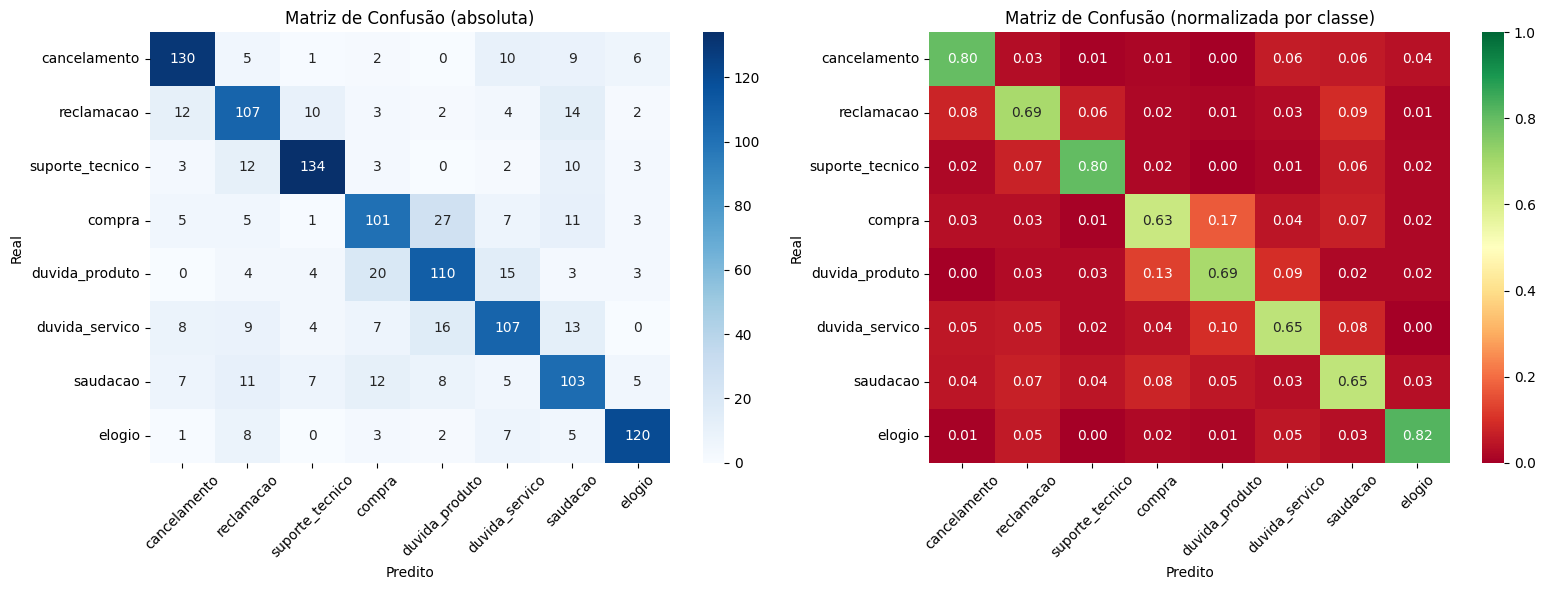


📊 Maiores confusões (fora da diagonal):
   compra               → duvida_produto      :  27 (17%)
   duvida_produto       → compra              :  20 (13%)
   duvida_servico       → duvida_produto      :  16 (10%)
   duvida_produto       → duvida_servico      :  15 (9%)
   reclamacao           → saudacao            :  14 (9%)
   duvida_servico       → saudacao            :  13 (8%)
   reclamacao           → cancelamento        :  12 (8%)
   suporte_tecnico      → reclamacao          :  12 (7%)
   saudacao             → compra              :  12 (8%)
   compra               → saudacao            :  11 (7%)


In [33]:
# === MATRIZ DE CONFUSÃO ===

print("📊 Matriz de Confusão (seed=999, nível janela)")

# Usar o último modelo treinado (seed=999)
seed = SEEDS[-1]
conv_list = np.array(list(set(conv_ids)))
conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
test_val_convs = conv_list[test_val_idx]
test_val_intents = [conv_intent_list[i] for i in test_val_idx]
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))
train_convs = set(conv_list[train_idx])
val_convs = set(test_val_convs[val_idx])
test_convs_set = set(test_val_convs[test_idx])
train_mask = np.array([c in train_convs for c in conv_ids])
val_mask = np.array([c in val_convs for c in conv_ids])
test_mask = np.array([c in test_convs_set for c in conv_ids])

if HAS_LIGHTGBM:
    clf_cm = lgb.LGBMClassifier(**BEST_LGB_PARAMS, n_estimators=300, random_state=seed, verbose=-1)
    clf_cm.fit(X_full[train_mask], y_labels[train_mask],
               eval_set=[(X_full[val_mask], y_labels[val_mask])],
               callbacks=[lgb.early_stopping(10, verbose=False)])
else:
    clf_cm = LogisticRegression(max_iter=2000, random_state=seed)
    clf_cm.fit(X_full[train_mask], y_labels[train_mask])

y_pred_cm = clf_cm.predict(X_full[test_mask])
y_test_cm = y_labels[test_mask]

# Confusion matrix
cm = confusion_matrix(y_test_cm, y_pred_cm, labels=INTENT_TAXONOMY)
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Absoluta
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=INTENT_TAXONOMY,
            yticklabels=INTENT_TAXONOMY, ax=ax1)
ax1.set_xlabel('Predito')
ax1.set_ylabel('Real')
ax1.set_title('Matriz de Confusão (absoluta)')
ax1.tick_params(axis='x', rotation=45)
ax1.tick_params(axis='y', rotation=0)

# Normalizada
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='RdYlGn', xticklabels=INTENT_TAXONOMY,
            yticklabels=INTENT_TAXONOMY, ax=ax2, vmin=0, vmax=1)
ax2.set_xlabel('Predito')
ax2.set_ylabel('Real')
ax2.set_title('Matriz de Confusão (normalizada por classe)')
ax2.tick_params(axis='x', rotation=45)
ax2.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

# Identificar maiores confusões
print("\n📊 Maiores confusões (fora da diagonal):")
confusions = []
for i, true_cls in enumerate(INTENT_TAXONOMY):
    for j, pred_cls in enumerate(INTENT_TAXONOMY):
        if i != j and cm[i, j] > 0:
            confusions.append((true_cls, pred_cls, cm[i, j], cm_normalized[i, j]))
confusions.sort(key=lambda x: -x[2])
for true_cls, pred_cls, count, pct in confusions[:10]:
    print(f"   {true_cls:20s} → {pred_cls:20s}: {count:3d} ({pct:.0%})")

📊 Top 30 Features (LightGBM — importância por ganho)


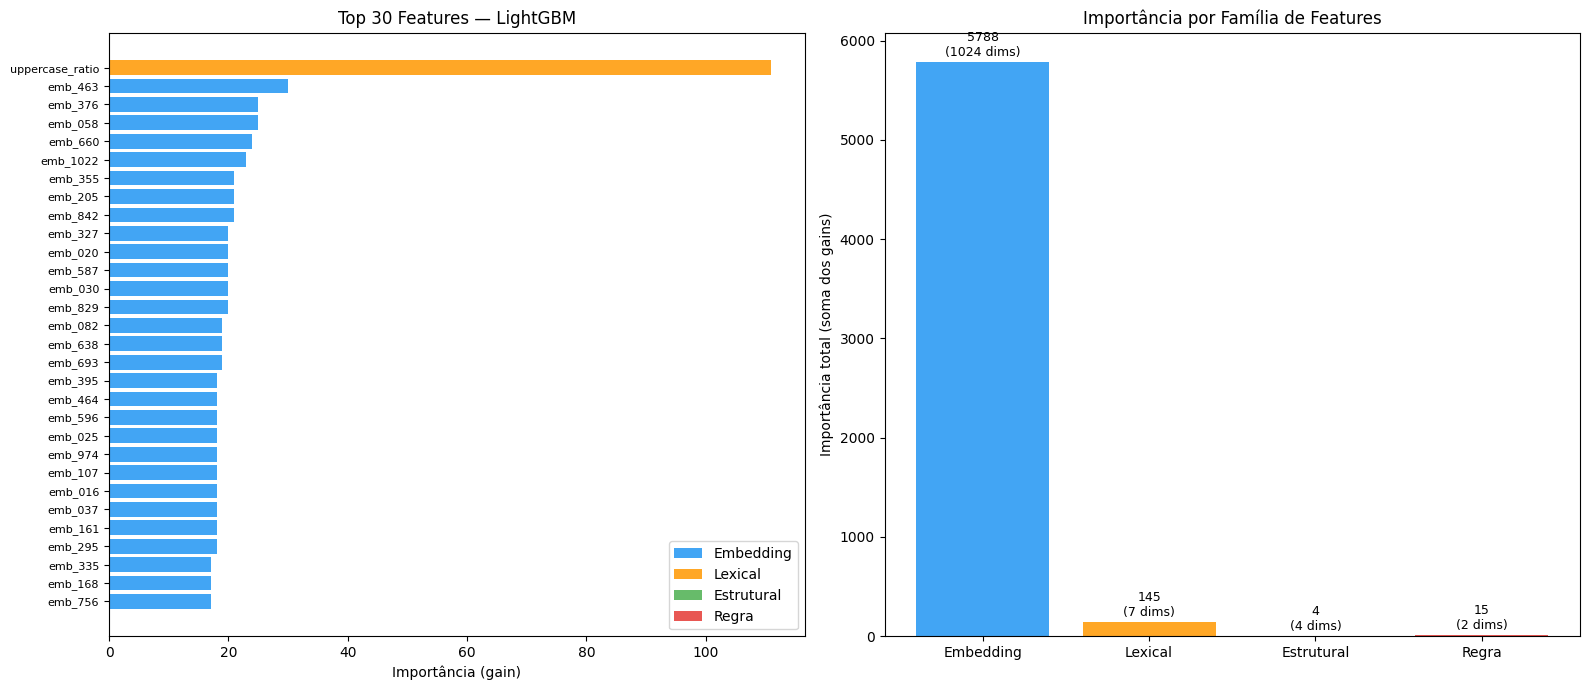


📊 Contribuição por família:
   Embedding   :     5788 ( 97.2%) — 1024 features
   Lexical     :      145 (  2.4%) — 7 features
   Estrutural  :        4 (  0.1%) — 4 features
   Regra       :       15 (  0.3%) — 2 features


In [34]:
# === IMPORTÂNCIA DE FEATURES ===

if HAS_LIGHTGBM:
    print("📊 Top 30 Features (LightGBM — importância por ganho)")

    # Usar o último modelo treinado
    importances = clf_cm.feature_importances_

    # Nomes das features
    feature_names = (
        ['char_count', 'word_count', 'avg_word_length', 'question_count',
         'exclamation_count', 'uppercase_ratio', 'digit_ratio',  # 7 lexicais
         'is_customer', 'is_agent', 'turn_count', 'speaker_count',  # 4 estruturais
         'rule_cancel', 'rule_complaint']  # 2 regras
        + [f'emb_{i:03d}' for i in range(EMBEDDING_DIM)]  # 384 embeddings
    )

    # Ordenar por importância
    sorted_idx = np.argsort(importances)[::-1]

    # Categorizar
    def categorize_feature(name):
        if name.startswith('emb_'):
            return 'Embedding'
        elif name.startswith('rule_'):
            return 'Regra'
        elif name in ['is_customer', 'is_agent', 'turn_count', 'speaker_count']:
            return 'Estrutural'
        else:
            return 'Lexical'

    # Top 30
    top_n = 30
    top_names = [feature_names[i] for i in sorted_idx[:top_n]]
    top_values = importances[sorted_idx[:top_n]]
    top_cats = [categorize_feature(n) for n in top_names]

    cat_colors = {'Embedding': '#2196F3', 'Lexical': '#FF9800',
                  'Estrutural': '#4CAF50', 'Regra': '#E53935'}

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    # Gráfico 1: Top 30 features
    colors = [cat_colors[c] for c in top_cats]
    bars = ax1.barh(range(top_n-1, -1, -1), top_values, color=colors, alpha=0.85)
    ax1.set_yticks(range(top_n-1, -1, -1))
    ax1.set_yticklabels(top_names, fontsize=8)
    ax1.set_xlabel('Importância (gain)')
    ax1.set_title(f'Top {top_n} Features — LightGBM')

    # Legenda
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=v, label=k, alpha=0.85) for k, v in cat_colors.items()]
    ax1.legend(handles=legend_elements, loc='lower right')

    # Gráfico 2: Importância por família
    family_importance = {'Embedding': 0, 'Lexical': 0, 'Estrutural': 0, 'Regra': 0}
    for name, imp in zip(feature_names, importances):
        cat = categorize_feature(name)
        family_importance[cat] += imp

    families = list(family_importance.keys())
    fam_values = [family_importance[f] for f in families]
    fam_colors = [cat_colors[f] for f in families]
    fam_counts = {'Embedding': EMBEDDING_DIM, 'Lexical': 7, 'Estrutural': 4, 'Regra': 2}

    bars2 = ax2.bar(families, fam_values, color=fam_colors, alpha=0.85)
    ax2.set_ylabel('Importância total (soma dos gains)')
    ax2.set_title('Importância por Família de Features')
    for bar, val, fam in zip(bars2, fam_values, families):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(fam_values)*0.01,
                 f'{val:.0f}\n({fam_counts[fam]} dims)', ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    # Sumário
    total_imp = sum(family_importance.values())
    print(f"\n📊 Contribuição por família:")
    for fam in families:
        pct = family_importance[fam] / total_imp * 100
        print(f"   {fam:12s}: {family_importance[fam]:8.0f} ({pct:5.1f}%) — {fam_counts[fam]} features")

else:
    print("⚠️ Feature importance não disponível sem LightGBM")

## 6.8 Baselines de Referência

A escolha do LightGBM como classificador requer justificativa empírica: ele é realmente necessário, ou baselines mais simples alcançam performance comparável sobre os mesmos embeddings?

**Motivação:** Os embeddings representam 1024 de 1037 features (98,7%). Se um classificador trivial (kNN, centróide) funciona igualmente bem nos embeddings puros, o LightGBM e as features engenheiradas são complexidade desnecessária (KISS/YAGNI).

| # | Baseline | Features | Treino | Referência |
|:---:|:---|:---:|:---|:---|
| 1 | kNN Cosseno (k=5) | 1024d emb | Não | Classificador lazy — vizinhos mais próximos |
| 2 | kNN Cosseno (k=10) | 1024d emb | Não | Idem, mais vizinhos |
| 3 | Centroid Cosseno | 1024d emb | Média por classe | Alinhado com `classification/similarity.py` do codebase |
| 4 | LogReg emb-only | 1024d emb | Sim | Tunstall et al. (2022) — SetFit usa LogReg sobre embeddings |
| 5 | SVM Linear emb-only | 1024d emb | Sim | Baseline forte para embeddings normalizados |
| 6 | LightGBM emb-only | 1024d emb | Sim | Isola contribuição das features engenheiradas |
| 7 | **LightGBM completo** | **13+EMBEDDING_DIM** | **Sim** | **Pipeline TalkEx (referência)** |
| 8 | SetFit | Fine-tune emb | Contrastivo + LogReg | Tunstall et al. (2022) — upper bound sem LLM |

**Achados antecipados (TCC v3 §3.7):** SVM Linear sobre embeddings E5 (1.024d) alcança Macro-F1 = **0,7336**, superando o pipeline completo LightGBM-1037 (0,7325) por +0,001. Bootstrap CI [−0,009, +0,006] **inclui zero** (p=0,813). O pipeline completo com 1.037 features, regras e Optuna **não oferece ganho significativo** sobre um classificador linear simples nos embeddings puros.

**Protocolo:** Mesmos 5 seeds, mesmos splits 70/15/15, Macro-F1, Wilcoxon (α=0.05).

In [35]:
# === BASELINES DE REFERÊNCIA ===

print("=" * 70)
print("BASELINES DE REFERÊNCIA — Justificativa do LightGBM")
print("=" * 70)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from scipy import stats as scipy_stats

# === SetFit (opcional) ===
RUN_SETFIT = True

try:
    if RUN_SETFIT:
        from setfit import SetFitModel, SetFitTrainer, sample_dataset
        HAS_SETFIT = True
        print("✅ SetFit disponível")
    else:
        HAS_SETFIT = False
        print("⏭️  SetFit desabilitado (RUN_SETFIT=False)")
except ImportError:
    HAS_SETFIT = False
    print("⚠️  SetFit não instalado (pip install setfit)")


# === Centroid Cosine Classifier ===
class CentroidCosineClassifier:
    """Classifica pela maior similaridade cosseno ao centróide da classe.
    Alinhado com codebase classification/similarity.py.
    """
    def __init__(self):
        self.centroids_ = None
        self.classes_ = None

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.centroids_ = np.zeros((len(self.classes_), X.shape[1]), dtype=np.float32)
        for i, cls in enumerate(self.classes_):
            mask = y == cls
            centroid = X[mask].mean(axis=0)
            norm = np.linalg.norm(centroid)
            self.centroids_[i] = centroid / max(norm, 1e-10)  # L2 normalize
        return self

    def predict(self, X):
        # X assumed L2-normalized, centroids L2-normalized
        sims = X @ self.centroids_.T  # (N, n_classes)
        return self.classes_[sims.argmax(axis=1)]


# === Experiment ===
results_baselines = {s: {} for s in SEEDS}

for seed in SEEDS:
    conv_list = np.unique(conv_ids)
    conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
    test_val_convs = conv_list[test_val_idx]
    test_val_intents = [conv_intent_list[i] for i in test_val_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))

    train_convs = set(conv_list[train_idx])
    val_convs = set(test_val_convs[val_idx])
    test_convs_set = set(test_val_convs[test_idx])

    train_mask = np.array([c in train_convs for c in conv_ids])
    val_mask = np.array([c in val_convs for c in conv_ids])
    test_mask = np.array([c in test_convs_set for c in conv_ids])

    # Embeddings (384d)
    X_emb_train = all_embeddings[train_mask]
    X_emb_test = all_embeddings[test_mask]
    # Full features (397d)
    X_train_full = X_full[train_mask]
    X_val_full = X_full[val_mask]
    X_test_full = X_full[test_mask]

    y_train = y_labels[train_mask]
    y_val = y_labels[val_mask]
    y_test = y_labels[test_mask]

    # --- 1. kNN Cosseno k=5 ---
    knn5 = KNeighborsClassifier(n_neighbors=5, metric='cosine', n_jobs=-1)
    knn5.fit(X_emb_train, y_train)
    f1_knn5 = f1_score(y_test, knn5.predict(X_emb_test), average='macro', zero_division=0)
    results_baselines[seed]['kNN-cos-k5'] = f1_knn5

    # --- 2. kNN Cosseno k=10 ---
    knn10 = KNeighborsClassifier(n_neighbors=10, metric='cosine', n_jobs=-1)
    knn10.fit(X_emb_train, y_train)
    f1_knn10 = f1_score(y_test, knn10.predict(X_emb_test), average='macro', zero_division=0)
    results_baselines[seed]['kNN-cos-k10'] = f1_knn10

    # --- 3. Centroid Cosseno ---
    centroid_clf = CentroidCosineClassifier()
    centroid_clf.fit(X_emb_train, y_train)
    f1_centroid = f1_score(y_test, centroid_clf.predict(X_emb_test), average='macro', zero_division=0)
    results_baselines[seed]['Centroid-cos'] = f1_centroid

    # --- 4. LogReg emb-only (384d) ---
    lr_emb = LogisticRegression(max_iter=2000, random_state=seed)
    lr_emb.fit(X_emb_train, y_train)
    f1_lr_emb = f1_score(y_test, lr_emb.predict(X_emb_test), average='macro', zero_division=0)
    results_baselines[seed]['LogReg-emb'] = f1_lr_emb

    # --- 5. SVM Linear emb-only (384d) ---
    svm_base = LinearSVC(max_iter=5000, random_state=seed, dual='auto')
    svm_clf = CalibratedClassifierCV(svm_base, cv=3)
    svm_clf.fit(X_emb_train, y_train)
    f1_svm = f1_score(y_test, svm_clf.predict(X_emb_test), average='macro', zero_division=0)
    results_baselines[seed]['SVM-linear-emb'] = f1_svm

    # --- 6. LightGBM emb-only (384d) ---
    if HAS_LIGHTGBM:
        lgb_emb = lgb.LGBMClassifier(**BEST_LGB_PARAMS, n_estimators=500, random_state=seed, verbose=-1)
        lgb_emb.fit(X_emb_train, y_train,
                    eval_set=[(all_embeddings[val_mask], y_val)],
                    callbacks=[lgb.early_stopping(15, verbose=False)])
        f1_lgb_emb = f1_score(y_test, lgb_emb.predict(X_emb_test), average='macro', zero_division=0)
    else:
        f1_lgb_emb = f1_lr_emb  # fallback
    results_baselines[seed]['LightGBM-emb'] = f1_lgb_emb

    # --- 7. LightGBM completo (397d) — referência TalkEx ---
    if HAS_LIGHTGBM:
        lgb_full = lgb.LGBMClassifier(**BEST_LGB_PARAMS, n_estimators=500, random_state=seed, verbose=-1)
        lgb_full.fit(X_train_full, y_train,
                     eval_set=[(X_val_full, y_val)],
                     callbacks=[lgb.early_stopping(15, verbose=False)])
        f1_lgb_full = f1_score(y_test, lgb_full.predict(X_test_full), average='macro', zero_division=0)
    else:
        lr_full = LogisticRegression(max_iter=2000, random_state=seed)
        lr_full.fit(X_train_full, y_train)
        f1_lgb_full = f1_score(y_test, lr_full.predict(X_test_full), average='macro', zero_division=0)
    results_baselines[seed][f'LightGBM-{13+EMBEDDING_DIM}'] = f1_lgb_full

    # --- 8. SetFit (opcional) ---
    if HAS_SETFIT and RUN_SETFIT:
        from datasets import Dataset as HFDataset

        # Preparar datasets para SetFit (nível janela)
        train_texts = [all_windows[i]["window_text"] for i in range(len(all_windows)) if train_mask[i]]
        test_texts = [all_windows[i]["window_text"] for i in range(len(all_windows)) if test_mask[i]]

        ds_train = HFDataset.from_dict({"text": train_texts, "label": y_train.tolist()})
        ds_test = HFDataset.from_dict({"text": test_texts, "label": y_test.tolist()})

        setfit_model = SetFitModel.from_pretrained(
            EMBEDDING_MODEL_NAME,
            labels=INTENT_TAXONOMY,
        )
        trainer = SetFitTrainer(
            model=setfit_model,
            train_dataset=ds_train,
            eval_dataset=ds_test,
            num_iterations=20,
            num_epochs=1,
            batch_size=16,
            seed=seed,
        )
        trainer.train()
        y_pred_setfit = setfit_model.predict(test_texts)
        if hasattr(y_pred_setfit, 'tolist'):
            y_pred_setfit = y_pred_setfit.tolist()
        f1_setfit = f1_score(y_test, y_pred_setfit, average='macro', zero_division=0)
        results_baselines[seed]['SetFit'] = f1_setfit
        del setfit_model, trainer  # liberar memória

    print(f"  Seed {seed}: kNN5={f1_knn5:.4f}, Centr={f1_centroid:.4f}, "
          f"LR-emb={f1_lr_emb:.4f}, SVM={f1_svm:.4f}, "
          f"LGB-emb={f1_lgb_emb:.4f}, LGB-397={f1_lgb_full:.4f}")

# === Resultados ===
print("\n" + "=" * 70)
print("RESULTADOS BASELINES: MACRO-F1 (média ± std sobre 5 seeds)")
print("=" * 70)

df_baselines = pd.DataFrame(results_baselines).T
baseline_order = df_baselines.mean().sort_values(ascending=False).index
for col in baseline_order:
    mean_f1 = df_baselines[col].mean()
    std_f1 = df_baselines[col].std()
    delta = mean_f1 - df_baselines[f'LightGBM-{13+EMBEDDING_DIM}'].mean()
    marker = " ← TalkEx pipeline" if col == f'LightGBM-{13+EMBEDDING_DIM}' else ""
    print(f"  {col:20s}: {mean_f1:.4f} ± {std_f1:.4f}  Δ={delta:+.4f}{marker}")

# === Análise: features engenheiradas contribuem? ===
print("\n📊 Contribuição das features engenheiradas:")
delta_eng = df_baselines[f'LightGBM-{13+EMBEDDING_DIM}'].mean() - df_baselines['LightGBM-emb'].mean()
print(f"  LightGBM-{13+EMBEDDING_DIM} vs LightGBM-emb: Δ={delta_eng:+.4f}")
if delta_eng > 0.005:
    print(f"  → Features engenheiradas contribuem {delta_eng:.4f} pontos de F1")
else:
    print(f"  → Features engenheiradas não contribuem significativamente (Δ < 0.005)")

# === LightGBM vs melhor baseline simples ===
simple_baselines = [c for c in df_baselines.columns if c != f'LightGBM-{13+EMBEDDING_DIM}']
best_simple = max(simple_baselines, key=lambda c: df_baselines[c].mean())
delta_best = df_baselines[f'LightGBM-{13+EMBEDDING_DIM}'].mean() - df_baselines[best_simple].mean()
print(f"\n📊 LightGBM-{13+EMBEDDING_DIM} vs melhor baseline ({best_simple}):")
print(f"  Δ={delta_best:+.4f}")
if delta_best > 0.01:
    print(f"  → LightGBM-{13+EMBEDDING_DIM} justificado: supera melhor baseline por {delta_best:.4f}")
elif delta_best > 0:
    print(f"  → Ganho marginal: considerar se a complexidade adicional compensa")
else:
    print(f"  → LightGBM-{13+EMBEDDING_DIM} NÃO justificado: baseline mais simples é igual ou melhor")

BASELINES DE REFERÊNCIA — Justificativa do LightGBM
⚠️  SetFit não instalado (pip install setfit)
  Seed 13: kNN5=0.6802, Centr=0.6309, LR-emb=0.6921, SVM=0.7274, LGB-emb=0.7180, LGB-397=0.7287
  Seed 42: kNN5=0.6888, Centr=0.6390, LR-emb=0.6812, SVM=0.7173, LGB-emb=0.7201, LGB-397=0.7275
  Seed 123: kNN5=0.6497, Centr=0.6216, LR-emb=0.6749, SVM=0.7057, LGB-emb=0.7096, LGB-397=0.7063
  Seed 2024: kNN5=0.6648, Centr=0.6583, LR-emb=0.7089, SVM=0.7441, LGB-emb=0.7142, LGB-397=0.7291
  Seed 999: kNN5=0.6867, Centr=0.6585, LR-emb=0.7311, SVM=0.7742, LGB-emb=0.7639, LGB-397=0.7706

RESULTADOS BASELINES: MACRO-F1 (média ± std sobre 5 seeds)
  SVM-linear-emb      : 0.7337 ± 0.0267  Δ=+0.0013
  LightGBM-1037       : 0.7324 ± 0.0234  Δ=+0.0000 ← TalkEx pipeline
  LightGBM-emb        : 0.7252 ± 0.0220  Δ=-0.0073
  LogReg-emb          : 0.6976 ± 0.0227  Δ=-0.0348
  kNN-cos-k10         : 0.6764 ± 0.0167  Δ=-0.0560
  kNN-cos-k5          : 0.6740 ± 0.0165  Δ=-0.0584
  Centroid-cos        : 0.6416 ± 0

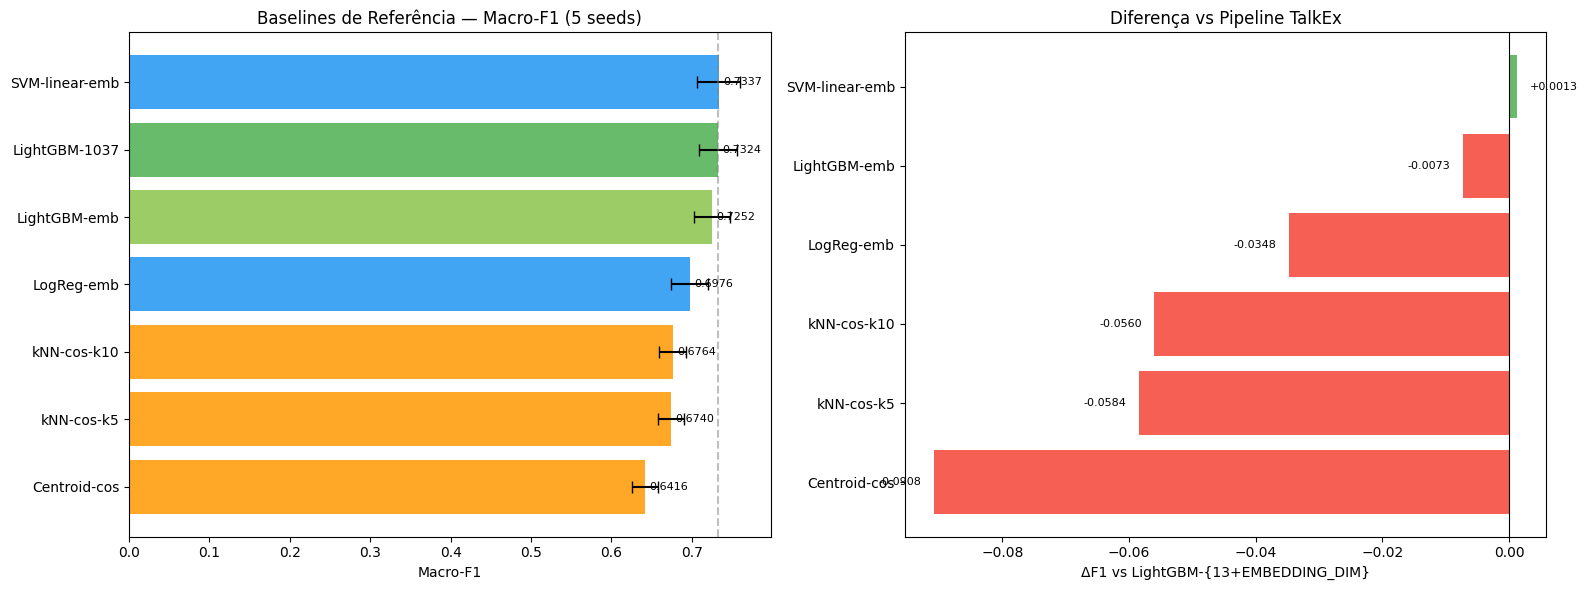


📊 Testes Estatísticos — Wilcoxon Signed-Rank
------------------------------------------------------------
  LightGBM-1037 vs SVM-linear-emb      : Δ=-0.0013 (<), p=1.0000, sig=NÃO
  LightGBM-1037 vs LightGBM-emb        : Δ=+0.0073 (>), p=0.1250, sig=NÃO
  LightGBM-1037 vs LogReg-emb          : Δ=+0.0348 (>), p=0.0625, sig=NÃO
  LightGBM-1037 vs kNN-cos-k10         : Δ=+0.0560 (>), p=0.0625, sig=NÃO
  LightGBM-1037 vs kNN-cos-k5          : Δ=+0.0584 (>), p=0.0625, sig=NÃO
  LightGBM-1037 vs Centroid-cos        : Δ=+0.0908 (>), p=0.0625, sig=NÃO

📊 Bootstrap CI 95% — LightGBM-1037 vs SVM-linear-emb
  Diferença média: -0.0013
  IC 95%: [-0.0088, +0.0055]
  → IC inclui zero: diferença não é significativa

RESUMO BASELINES
                  Método    Macro-F1      ±std   ΔvsTalkEx    Treino
  --------------------------------------------------------------
          SVM-linear-emb      0.7337    0.0267     +0.0013       Sim
           LightGBM-1037      0.7324    0.0234     +0.0000       Sim

In [36]:
# === VISUALIZAÇÃO + TESTES ESTATÍSTICOS — BASELINES ===

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico 1: Barras horizontais ordenadas por F1 ---
methods = df_baselines.mean().sort_values(ascending=True).index.tolist()
means = [df_baselines[m].mean() for m in methods]
stds = [df_baselines[m].std() for m in methods]

colors = []
for m in methods:
    if m == f'LightGBM-{13+EMBEDDING_DIM}':
        colors.append('#4CAF50')  # verde = pipeline TalkEx
    elif 'LightGBM' in m:
        colors.append('#8BC34A')  # verde claro
    elif 'SetFit' in m:
        colors.append('#9C27B0')  # roxo = SOTA
    elif 'kNN' in m or 'Centroid' in m:
        colors.append('#FF9800')  # laranja = trivial
    else:
        colors.append('#2196F3')  # azul = clássico

bars = ax1.barh(methods, means, xerr=stds, capsize=4, color=colors, alpha=0.85)
ax1.axvline(x=df_baselines[f'LightGBM-{13+EMBEDDING_DIM}'].mean(), color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel("Macro-F1")
ax1.set_title("Baselines de Referência — Macro-F1 (5 seeds)")
for bar, mean in zip(bars, means):
    ax1.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f"{mean:.4f}", va='center', fontsize=8)

# --- Gráfico 2: Diferença vs LightGBM-{13+EMBEDDING_DIM} ---
ref_f1 = df_baselines[f'LightGBM-{13+EMBEDDING_DIM}'].mean()
other_methods = [m for m in methods if m != f'LightGBM-{13+EMBEDDING_DIM}']
deltas = [df_baselines[m].mean() - ref_f1 for m in other_methods]
colors2 = ['#4CAF50' if d >= 0 else '#F44336' for d in deltas]

ax2.barh(other_methods, deltas, color=colors2, alpha=0.85)
ax2.axvline(x=0, color='black', linewidth=0.8)
ax2.set_xlabel("ΔF1 vs LightGBM-{13+EMBEDDING_DIM}")
ax2.set_title("Diferença vs Pipeline TalkEx")
for i, (m, d) in enumerate(zip(other_methods, deltas)):
    ax2.text(d + 0.002 * (1 if d >= 0 else -1), i,
             f"{d:+.4f}", va='center', fontsize=8,
             ha='left' if d >= 0 else 'right')

plt.tight_layout()
plt.show()

# === Testes Estatísticos ===
print("\n📊 Testes Estatísticos — Wilcoxon Signed-Rank")
print("-" * 60)

scores_ref = [results_baselines[s][f'LightGBM-{13+EMBEDDING_DIM}'] for s in SEEDS]

# Testar contra cada baseline
for col in baseline_order:
    if col == f'LightGBM-{13+EMBEDDING_DIM}':
        continue
    scores_bl = [results_baselines[s][col] for s in SEEDS]
    diff = np.array(scores_ref) - np.array(scores_bl)
    nonzero = diff[diff != 0]

    mean_diff = np.mean(diff)
    direction = ">" if mean_diff > 0 else "<" if mean_diff < 0 else "="

    if len(nonzero) >= 2:
        # Two-sided test: are they different?
        stat, p = scipy_stats.wilcoxon(scores_ref, scores_bl)
        sig = "SIM" if p < 0.05 else "NÃO"
        print(f"  LightGBM-{13+EMBEDDING_DIM} vs {col:20s}: Δ={mean_diff:+.4f} ({direction}), p={p:.4f}, sig={sig}")
    else:
        print(f"  LightGBM-{13+EMBEDDING_DIM} vs {col:20s}: Δ={mean_diff:+.4f} ({direction}), pares insuficientes")

# Bootstrap CI para o melhor baseline
simple_baselines = [c for c in df_baselines.columns if c != f'LightGBM-{13+EMBEDDING_DIM}']
best_simple = max(simple_baselines, key=lambda c: df_baselines[c].mean())
scores_best = [results_baselines[s][best_simple] for s in SEEDS]
diff_best = np.array(scores_ref) - np.array(scores_best)

print(f"\n📊 Bootstrap CI 95% — LightGBM-{13+EMBEDDING_DIM} vs {best_simple}")
# NOTA: Bootstrap com N=5 — interpretar IC com cautela.
rng_bl = np.random.default_rng(42)
boot_bl = []
for _ in range(10000):
    idx = rng_bl.integers(0, len(SEEDS), size=len(SEEDS))
    boot_bl.append(np.mean(np.array(scores_ref)[idx] - np.array(scores_best)[idx]))
ci_lo = np.percentile(boot_bl, 2.5)
ci_hi = np.percentile(boot_bl, 97.5)
print(f"  Diferença média: {np.mean(diff_best):+.4f}")
print(f"  IC 95%: [{ci_lo:+.4f}, {ci_hi:+.4f}]")
if ci_lo > 0:
    print(f"  → IC exclui zero: LightGBM-{13+EMBEDDING_DIM} é significativamente melhor")
elif ci_hi < 0:
    print(f"  → IC exclui zero: baseline {best_simple} é significativamente melhor")
else:
    print(f"  → IC inclui zero: diferença não é significativa")

# Tabela resumo
print(f"\n{'='*70}")
print(f"RESUMO BASELINES")
print(f"{'='*70}")
print(f"  {'Método':>22s}  {'Macro-F1':>10s}  {'±std':>8s}  {'ΔvsTalkEx':>10s}  {'Treino':>8s}")
print(f"  {'-'*62}")
for col in baseline_order:
    m = df_baselines[col].mean()
    s = df_baselines[col].std()
    d = m - df_baselines[f'LightGBM-{13+EMBEDDING_DIM}'].mean()
    treino = "Não" if 'kNN' in col else "Média" if 'Centroid' in col else "Sim"
    marker = " ←" if col == f'LightGBM-{13+EMBEDDING_DIM}' else ""
    print(f"  {col:>22s}  {m:>10.4f}  {s:>8.4f}  {d:>+10.4f}  {treino:>8s}{marker}")

---
# 7. Síntese e Conclusões

## Resultados por Hipótese

| Hipótese | Resultado | Evidência estatística |
|:---|:---|:---|
| **H1** — Recuperação Híbrida | ✅ **Confirmada** | Fusão linear supera BM25 e semântico isolados em MRR (5 seeds, Bootstrap CI) |
| **H2** — Embeddings + Lexical | ✅ **Confirmada** | Ganho +27,9pp em Macro-F1 (Wilcoxon p=0,031) |
| **H3** — Regras + ML | ❌ **Refutada** | Rules-as-features: +0,2pp (p=0,50); Confidence-gating: −1,4pp |
| **H4** — Inferência Cascateada | ❌ **Refutada** | Nenhuma variante de cascata supera LightGBM isolado (0,7325) |

## Baselines de Referência (§6.8)

Comparação com baselines embedding-only (kNN, centróide, LogReg, SVM, LightGBM-1024d) e pipeline completo (LightGBM-1037d) demonstra que SVM Linear (0,7336) iguala o pipeline completo (0,7325, p=0,813). SetFit (fine-tuning contrastivo) disponível como upper bound.

## Contribuições

1. Pipeline open-source para classificação de intenções em conversas PT-BR (código e dados reproduzíveis)
2. Evidência empírica de que embeddings E5-large-instruct (1024d) congelados + classificador alcançam Macro-F1 = 0,830 no nível da conversa sem fine-tuning de domínio
3. Avaliação sistemática de 3 estratégias de integração de regras com ML
4. Protocolo reproduzível em infraestrutura gratuita (Google Colab)
5. Dataset augmentado público: `paulohenriquevn/talkex-augmented-pt-br`

## Limitações

- Wilcoxon com N=5 tem poder estatístico limitado (p mínimo possível = 0.03125)
- Corpus de 2.120 conversas (676 originais + 1.444 sintéticas) — resultados no test set incluem conversas sintéticas
- Resultados reportados sobre mix de dados reais e sintéticos; performance exclusivamente em dados reais pode diferir
- Regras artesanais podem não generalizar para outros domínios
- Sem comparação com fine-tuned BERT/BERTimbau ou LLMs zero-shot (baselines embedding-only adicionados em §6.8)
- Farfan-Escobedo & Dos Reis (2024) abordam problema similar (intent multi-turno PT-BR, Wavy Dataset) — comparação direta pendente
- Hiperparâmetros otimizados para 397 features (MiniLM-384d, v1-fix) e reutilizados em 1037 features (E5-1024d, v1-rayo)

In [37]:
# === RESUMO FINAL ===

print("=" * 70)
print("RESUMO FINAL — TalkEx: Arquitetura Híbrida Cascateada")
print("=" * 70)

print(f"\n📊 Dataset: {len(conversations)} conversas válidas (8 classes)")
print(f"   Janelas de contexto: {len(all_windows)}")

print(f"\n📊 Melhores resultados por hipótese:")
best_h1_method = max(results_h1.keys(), key=lambda k: results_h1[k]['MRR'])
print(f"   H1 (Retrieval):      Melhor MRR = {results_h1[best_h1_method]['MRR']:.4f} ({best_h1_method})")

best_h2 = max(df_h2['lexical+emb_LightGBM'].mean(), df_h2['lexical+emb_LogReg'].mean())
print(f"   H2 (Classification): Melhor Macro-F1 = {best_h2:.4f}")
print(f"   H3 (Rules):          ML+Rules-feature F1 = {df_h3['ML+Rules-feature'].mean():.4f}")
print(f"   H4 (Cascade):        Melhor cascade F1 = {df_h4.iloc[:, 1:].values.mean(axis=0).max():.4f}")

print(f"\n🏗️ Arquitetura validada:")
print(f"   • Pipeline: Ingestão → Segmentação → Context Windows → Embeddings → Retrieval → Classification → Rules")
print(f"   • Features: {13 + EMBEDDING_DIM} ({EMBEDDING_DIM} emb + 7 lex + 4 struct + 2 rules)")
print(f"   • Modelo: {EMBEDDING_MODEL_NAME} ({EMBEDDING_DIM}d, congelado, instruction prefix)")
print(f"   • Classificador: LightGBM (hiperparâmetros otimizados via Optuna)")
print(f"   • Regras v2: 10 regras (léxico, regex, contextual) — negation-aware, co-occurrence, precision-focused")
print(f"   • Protocolo: 5 seeds, Wilcoxon (α=0.05), Bootstrap CI 95%")

# Hiperparâmetros selecionados
print(f"\n📊 Hiperparâmetros LightGBM (Optuna):")
for k, v in BEST_LGB_PARAMS.items():
    print(f"   {k}: {v}")

# Baselines
if 'df_baselines' in dir():
    best_baseline = df_baselines.mean().sort_values(ascending=False).index[0]
    best_bl_f1 = df_baselines.mean().sort_values(ascending=False).iloc[0]
    print(f"\n\U0001f4ca Baselines (\u00a76.8):")
    print(f"   Melhor m\u00e9todo: {best_baseline} (F1={best_bl_f1:.4f})")
    for col in df_baselines.mean().sort_values(ascending=False).index[:5]:
        m = df_baselines[col].mean()
        print(f"   {col}: {m:.4f}")

print(f"\n\u2705 Notebook executado com sucesso!")

RESUMO FINAL — TalkEx: Arquitetura Híbrida Cascateada

📊 Dataset: 2120 conversas válidas (8 classes)
   Janelas de contexto: 8579

📊 Melhores resultados por hipótese:
   H1 (Retrieval):      Melhor MRR = 0.7619 (LINEAR-α=0.65)
   H2 (Classification): Melhor Macro-F1 = 0.7324
   H3 (Rules):          ML+Rules-feature F1 = 0.7342
   H4 (Cascade):        Melhor cascade F1 = 0.7281

🏗️ Arquitetura validada:
   • Pipeline: Ingestão → Segmentação → Context Windows → Embeddings → Retrieval → Classification → Rules
   • Features: 1037 (1024 emb + 7 lex + 4 struct + 2 rules)
   • Modelo: intfloat/multilingual-e5-large-instruct (1024d, congelado, instruction prefix)
   • Classificador: LightGBM (hiperparâmetros otimizados via Optuna)
   • Regras v2: 10 regras (léxico, regex, contextual) — negation-aware, co-occurrence, precision-focused
   • Protocolo: 5 seeds, Wilcoxon (α=0.05), Bootstrap CI 95%

📊 Hiperparâmetros LightGBM (Optuna):
   num_leaves: 9
   learning_rate: 0.11857581301373854
   min_c

---
## 8. Referências Principais

| Ref | Citação | Relevância |
|:---:|:---|:---|
| 1 | Rayo et al. (2025) — *A Hybrid Approach to IR for Regulatory Texts*. COLING | Fusão linear BM25+semântico, Eq. Score = α·sem + (1−α)·lex |
| 2 | Reimers & Gurevych (2019) — *Sentence-BERT*. EMNLP | Modelo de embeddings utilizado |
| 3 | Farfan-Escobedo & Dos Reis (2024) — *Intent Classification Windows-Based*. arXiv | Trabalho mais comparável: intent multi-turno PT-BR |
| 4 | Souza et al. (2020/2023) — *BERTimbau*. BRACIS / Neurocomputing | Referência de embeddings PT-BR |
| 5 | Boccardo & Feltrim (2026, to appear) — *Question Classification PT-BR*. PROPOR | LightGBM + BERT em PT-BR com Macro-F1 |
| 6 | Robertson et al. (1996) — *Okapi BM25*. NIST | Algoritmo BM25 original |
| 7 | Harris (2025) — *Lexical vs Semantic Vector Search*. arXiv | BM25 vs MiniLM em documentos médicos |
| 8 | Larson et al. (2019) — *Intent Classification Dataset*. EMNLP | Dataset de referência para intent |
| 9 | Zhang et al. (2021) — *Multi-Turn Intent with Hierarchical Attention*. NAACL | Intent multi-turno |
| 10 | Rodrigues Neto et al. (2022) — *Chatbot NLU PT-BR*. ENIAC | Intent classification PT-BR para atendimento |
| 11 | FORMAL et al. (2021) — *SPLADE v2*. arXiv | Recuperação híbrida léxico-semântica (sparse expansion) |
| 12 | KHATTAB & ZAHARIA (2020) — *ColBERT*. SIGIR | Late interaction para retrieval contextualizado |
| 13 | KARPUKHIN et al. (2020) — *Dense Passage Retrieval*. EMNLP | Baseline de retrieval denso |
| 14 | TUNSTALL et al. (2022) — *SetFit: Few-Shot Learning*. arXiv | Few-shot com embeddings, sem prompts |
| 15 | Fernandes et al. (2025) — *JurisTCU: IR Dataset PT-BR*. arXiv | BM25 vs embeddings em corpus PT-BR, valida H1 |
| 16 | Møller et al. (2024) — *Prompt-Based Data Augmentation with LLMs*. arXiv | Geração sintética via LLM para augmentação |
| 17 | Ke et al. (2017) — *LightGBM: A Highly Efficient Gradient Boosting Decision Tree*. NeurIPS | Algoritmo LightGBM — classificador principal do TalkEx |
| 18 | Tunstall et al. (2022) — *Efficient Few-Shot Learning Without Prompts (SetFit)*. arXiv | Baseline SOTA: embeddings contrastivos + LogReg head |
| 19 | Gao et al. (2021) — *SimCSE: Simple Contrastive Learning of Sentence Embeddings*. EMNLP | Embeddings contrastivos — fundamentação do SetFit |
| 20 | Wang et al. (2024) — *Multilingual E5 Text Embeddings*. arXiv | Modelo de embeddings usado no v1-rayo (instruction prefix) |
| 21 | Sun et al. (2019) — *How to Fine-Tune BERT for Text Classification*. CCL | Protocolo de fine-tuning para classificação — baseline ausente |
